In [6]:
import os, sys
sys.path.append('C:\\_Lib\\python\\slab\\instruments')
sys.path.append('C:\\_Lib\\python') 
sys.path.append('C:\\_Lib\\python\\InstrumentControl\\Devices\\basel')
sys.path.append('C:\\_Lib\\python\\InstrumentControl')
sys.path.append('C:\\_Lib\\python\\InstrumentControl\\Devices\\RF_switch')
sys.path.append('C:\\_Lib\\python\\slab_qick_calib\\analysis')

import numpy as np
import matplotlib.pyplot as plt
from IPython.display import clear_output
import time
import pickle
import fitres
import basel
import RC2SP4TA18 as RF_switch
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from SignalCore import SignalCore
import datetime


In [7]:
import os
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from IPython.display import clear_output

WINDOWS_LIB_PATHS = [
    r"C:\\_Lib\\python\\slab\\instruments",
    r"C:\\_Lib\\python",
    r"C:\\_Lib\\python\\InstrumentControl\\Devices\\basel",
    r"C:\\_Lib\\python\\InstrumentControl",
    r"C:\\_Lib\\python\\InstrumentControl\\Devices\\RF_switch",
    r"C:\\_Lib\\python\\slab_qick_calib\\analysis",
    r"C:\\_Lib\\python\\slab_qick_calib\\notebooks\\SMPDs\\Daniel",
]

for lib_path in WINDOWS_LIB_PATHS:
    if lib_path not in sys.path:
        sys.path.append(lib_path)

import fitres
from SMPD_VNA import (
    FitResAdapter,
    PumpBiasScan,
    PowerScanAcquisition,
    PowerScanAnalyzer,
    RFSwitchChannelSurvey,
    SMPDVNA,
    VNASweepConfig,
    WasteBaseline,
    WasteResonanceZoom,
    load_pump_bias_scan_result,
    load_power_scan_result,
    NoiseReadoutStudy,
    load_sweep_result,
    plot_gain_heatmap,
)

%matplotlib inline


In [12]:
import RhodeSchwarz
import basel
import RC2SP4TA18 as RF_switch
from SignalCore import SignalCore

VNA_ADDRESS = "192.168.137.84"
RF_SWITCH_HOST = "192.168.137.131"
BFG_RF_SWITCH_HOST = "192.168.137.132"
SIGNALCORE_ADDRESS = "100026C4"
BASEL_CHANNEL = 12
JPA_OFF_BIAS_MV = 0
JPA_ON_BIAS_MV = 30.62
JPA_PUMP_POWER_DBM = -9.75
JPA_PUMP_FREQUENCY_HZ = 7740e6

RS = RhodeSchwarz.ZVB8(address=VNA_ADDRESS)
print(RS.get_id())

bias = basel.Basel(allowed_range_mv=15000)
bias.set_voltage_mV(BASEL_CHANNEL, voltage_mv=0)
bias.enable_output(BASEL_CHANNEL)

vna = SMPDVNA(RS, clear_output_func=clear_output, sleep_s=0.1)
fit_adapter = FitResAdapter(
    fitres,
    fit_type="reflection",
    hpd=True,
    phase_first=True,
)

waste_zoom = WasteResonanceZoom(vna, fit_adapter)
baseline_runner = WasteBaseline(vna)
power_scan_acquisition = PowerScanAcquisition(vna)


I'm Bat Mouse!
Rohde-Schwarz,ZNB26-4Port,1334333065100972,3.45

Connection OK
 to IP: ('192.168.137.217', 23)
Received: 0



In [110]:
power_scan_acquisition.acquire(
    powers_dbm=RFpowers,
    config=power_scan_config,
    save_path=POWER_SCAN_PATH,
    live_plot=True,
)

ValueError: No readout powers supplied.

In [118]:
RFpowers = np.arange(-50, -49, 1)
print(RFpowers)

[-50]


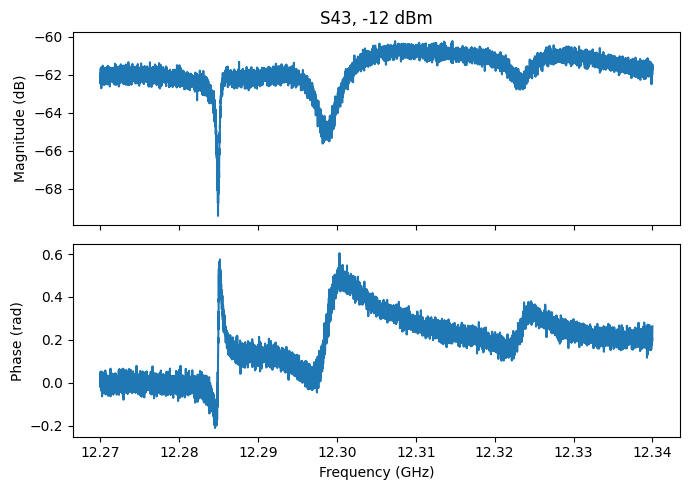

C:\_Data\SMPD\2026_05_25\Waymar_tunable_resonator_power_scan_higher_powers.h5


In [4]:
power_scan_config = VNASweepConfig(
    start_ghz=12.27,
    stop_ghz=12.34,
    step_ghz=0.075,
    points_per_segment=10001,
    measurement="S43",
    rf_power_dbm=-30,
    if_bw_hz=10000,
    avg_time_s=100,
    phase_fit_edge_fraction=0.1,
)

RFpowers = np.arange(-30, -10, 2)

# power_switch = RF_switch.RC2SP4TA18Controller(host=RF_SWITCH_HOST)
# power_switch.connect()
# power_switch.switch("B", 0)
# power_switch.disconnect()

POWER_SCAN_PATH = Path(r"C:/_Data/SMPD/2026_05_25/Waymar_tunable_resonator_power_scan_higher_powers.h5")

power_scan = power_scan_acquisition.acquire(
    powers_dbm=RFpowers,
    config=power_scan_config,
    save_path=POWER_SCAN_PATH,
    live_plot=True,

)

freq_pow_sweep = power_scan.freq_pow_sweep
mag_pow_sweep = power_scan.mag_pow_sweep
phase_pow_sweep = power_scan.phase_pow_sweep
RFpowers = list(power_scan.powers_dbm)
print(POWER_SCAN_PATH)


In [15]:
power_scan_higher

PowerScanResult(freq_pow_sweep=array([[12.27    , 12.270007, 12.270014, ..., 12.339986, 12.339993,
        12.34    ],
       [12.27    , 12.270007, 12.270014, ..., 12.339986, 12.339993,
        12.34    ],
       [12.27    , 12.270007, 12.270014, ..., 12.339986, 12.339993,
        12.34    ],
       ...,
       [12.27    , 12.270007, 12.270014, ..., 12.339986, 12.339993,
        12.34    ],
       [12.27    , 12.270007, 12.270014, ..., 12.339986, 12.339993,
        12.34    ],
       [12.27    , 12.270007, 12.270014, ..., 12.339986, 12.339993,
        12.34    ]]), mag_pow_sweep=array([[-62.29989947, -61.40981449, -62.66406137, ..., -61.14196371,
        -62.86977376, -61.19672745],
       [-62.25176924, -62.50767671, -61.17640709, ..., -60.10034443,
        -63.34890123, -63.05495158],
       [-61.34681997, -60.28158645, -61.50572909, ..., -62.61548239,
        -62.94540649, -63.16628628],
       ...,
       [-61.64606692, -62.61352177, -62.26826431, ..., -62.17096911,
        -61.53

[-50. -40. -35. -30. -28. -26. -24. -22. -20. -18. -16. -14. -12.]
Power: -50.0 dBm, Qi: 41356.15
Power: -40.0 dBm, Qi: 40182.96
Power: -35.0 dBm, Qi: 40160.02
Power: -30.0 dBm, Qi: 37637.02
Power: -28.0 dBm, Qi: 45530.93
Power: -26.0 dBm, Qi: 41351.57
Power: -24.0 dBm, Qi: 44472.46
Power: -22.0 dBm, Qi: 38129.76
Power: -20.0 dBm, Qi: 42839.47
Power: -18.0 dBm, Qi: 40689.05
Power: -16.0 dBm, Qi: 41208.03
Power: -14.0 dBm, Qi: 41358.15
Power: -12.0 dBm, Qi: 39022.60


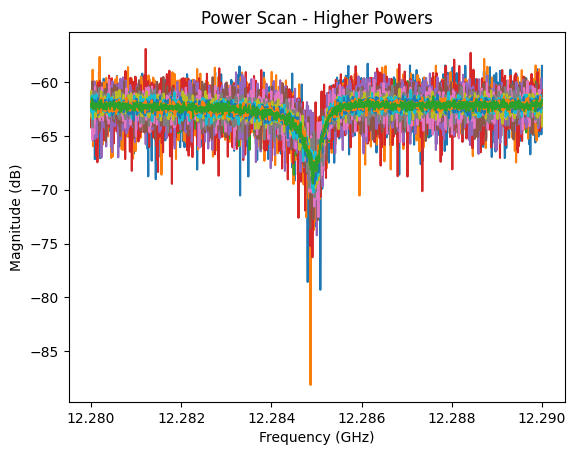

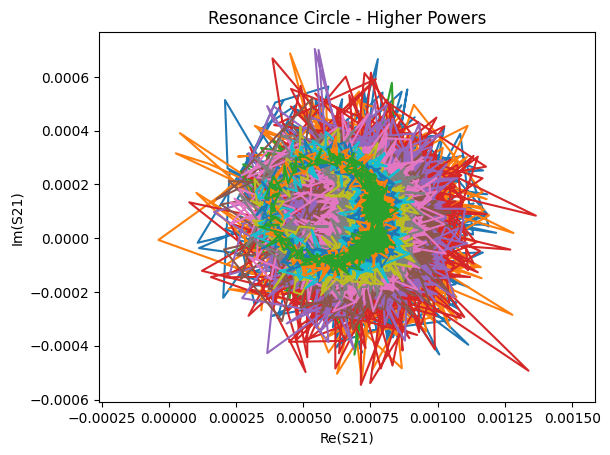

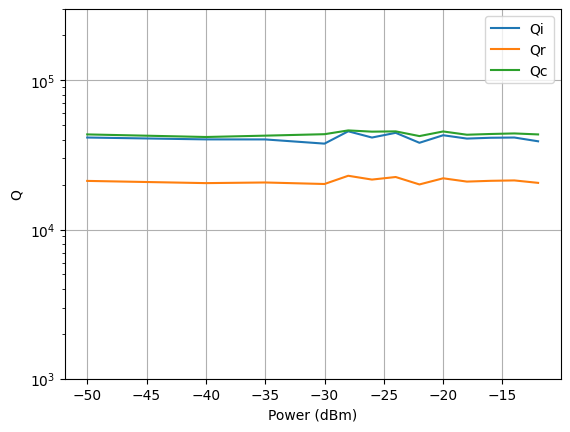

In [43]:
# load existing power scan result
power_scan_higher = load_power_scan_result(Path(r"C:/_Data/SMPD/2026_05_25/Waymar_tunable_resonator_power_scan_higher_powers.h5"))
power_scan_lower = load_power_scan_result(Path(r"C:/_Data/SMPD/2026_05_25/Waymar_tunable_resonator_power_scan_lowest_power.h5"))
power_scan_middle = load_power_scan_result(Path(r"C:/_Data/SMPD/2026_05_25/Waymar_tunable_resonator_power_scan.h5"))

powers = np.concatenate([power_scan_lower.powers_dbm, power_scan_middle.powers_dbm, power_scan_higher.powers_dbm])
print(powers) 

freq = np.concatenate([power_scan_lower.freq_pow_sweep, power_scan_middle.freq_pow_sweep, power_scan_higher.freq_pow_sweep], axis=0)
mag = np.concatenate([power_scan_lower.mag_pow_sweep, power_scan_middle.mag_pow_sweep, power_scan_higher.mag_pow_sweep], axis=0)
phase = np.concatenate([power_scan_lower.phase_pow_sweep, power_scan_middle.phase_pow_sweep, power_scan_higher.phase_pow_sweep], axis=0)

Qis = np.zeros_like(powers)
Qrs = np.zeros_like(powers)
Qcs = np.zeros_like(powers)
for j, power_dbm in enumerate(powers):
    # j = len(powers) - 1 - i

    mask = (freq[j,:] >= 12.28) & (freq[j,:] <= 12.29)
    S21 = 10**(mag[j,mask]/20) * np.exp(1j * phase[j,mask])

    params = fitres.finefit(freq[j,mask], S21,[12.285])
    Qr = params[1]
    Qc = params[-3]
    Qi = 1/(1/Qr - 1/Qc)
    print(f"Power: {power_dbm} dBm, Qi: {Qi:.2f}")
    Qis[j] = Qi
    Qrs[j] = Qr
    Qcs[j] = Qc

    plt.figure(1)
    plt.plot(freq[j,mask], mag[j,mask], label=f"{power_dbm} dBm",zorder=len(powers)-i)

    plt.xlabel("Frequency (GHz)")
    plt.ylabel("Magnitude (dB)")
    plt.title("Power Scan - Higher Powers")



    plt.figure(2)
    plt.plot(S21.real, S21.imag, label=f"{power_dbm} dBm",zorder=len(powers)-i)
    plt.xlabel("Re(S21)")
    plt.ylabel("Im(S21)")
    plt.gca().set_aspect('equal', adjustable='datalim')
    plt.title("Resonance Circle - Higher Powers")
    # plt.show()

    if i == len(powers) - 10 or i == 5:  # Only plot the fit for the highest and lowest power
        plt.figure()
        fit_plot = fitres.resfunc3(freq[j,mask], *params[:-3])
        plt.plot(S21.real, S21.imag, label="Data", color="blue", zorder=50)
        plt.plot(fit_plot.real, fit_plot.imag, label="Fit", color="red", zorder=100)

plt.figure()
plt.plot(powers, Qis,label='Qi')
plt.plot(powers, Qrs,label='Qr')
plt.plot(powers, Qcs,label='Qc')
plt.yscale("log")
plt.ylim(1e3,3e5)
plt.xlabel("Power (dBm)")
plt.ylabel("Q")
plt.legend()

plt.grid(True)

[-50. -40. -35. -30. -28. -26. -24. -22. -20. -18. -16. -14. -12.]
Power: -50.0 dBm, Qi: 4169.90
Power: -40.0 dBm, Qi: 4473.82
Power: -35.0 dBm, Qi: 4479.85
Power: -30.0 dBm, Qi: 4251.26
Power: -28.0 dBm, Qi: 4381.50
Power: -26.0 dBm, Qi: 4301.68
Power: -24.0 dBm, Qi: 4476.67
Power: -22.0 dBm, Qi: 4605.37
Power: -20.0 dBm, Qi: 4459.02
Power: -18.0 dBm, Qi: 4384.33
Power: -16.0 dBm, Qi: 4411.74
Power: -14.0 dBm, Qi: 4394.94
Power: -12.0 dBm, Qi: 4436.36


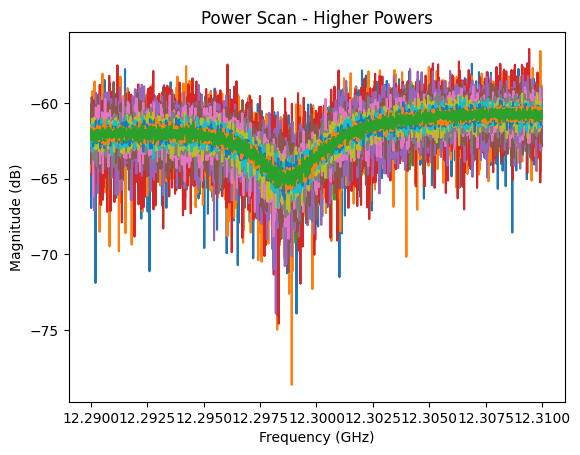

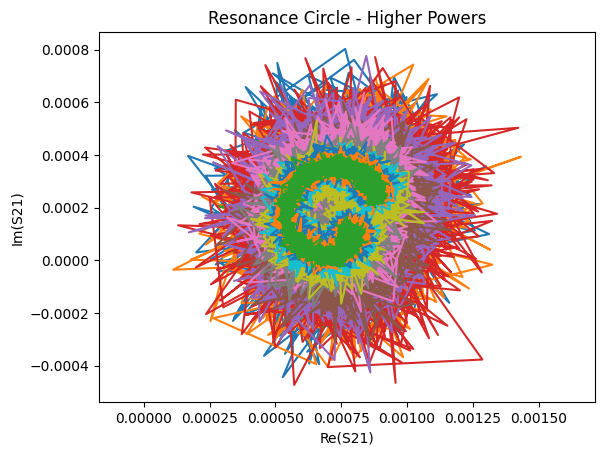

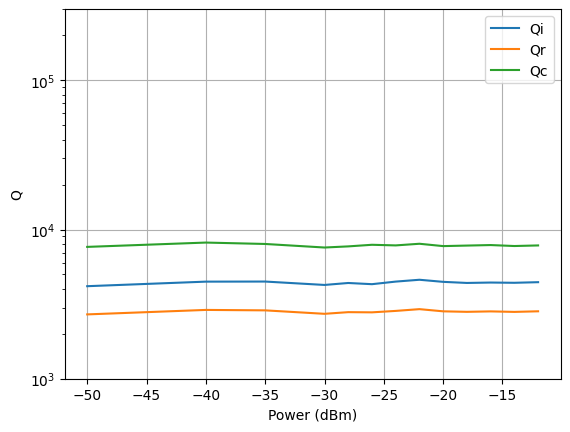

In [44]:
# load existing power scan result
power_scan_higher = load_power_scan_result(Path(r"C:/_Data/SMPD/2026_05_25/Waymar_tunable_resonator_power_scan_higher_powers.h5"))
power_scan_lower = load_power_scan_result(Path(r"C:/_Data/SMPD/2026_05_25/Waymar_tunable_resonator_power_scan_lowest_power.h5"))
power_scan_middle = load_power_scan_result(Path(r"C:/_Data/SMPD/2026_05_25/Waymar_tunable_resonator_power_scan.h5"))

powers = np.concatenate([power_scan_lower.powers_dbm, power_scan_middle.powers_dbm, power_scan_higher.powers_dbm])
print(powers) 

freq = np.concatenate([power_scan_lower.freq_pow_sweep, power_scan_middle.freq_pow_sweep, power_scan_higher.freq_pow_sweep], axis=0)
mag = np.concatenate([power_scan_lower.mag_pow_sweep, power_scan_middle.mag_pow_sweep, power_scan_higher.mag_pow_sweep], axis=0)
phase = np.concatenate([power_scan_lower.phase_pow_sweep, power_scan_middle.phase_pow_sweep, power_scan_higher.phase_pow_sweep], axis=0)

Qis = np.zeros_like(powers)
Qrs = np.zeros_like(powers)
Qcs = np.zeros_like(powers)
for j, power_dbm in enumerate(powers):
    # j = len(powers) - 1 - i

    mask = (freq[j,:] >= 12.29) & (freq[j,:] <= 12.31)
    S21 = 10**(mag[j,mask]/20) * np.exp(1j * phase[j,mask])

    params = fitres.finefit(freq[j,mask], S21,[12.30])
    Qr = params[1]
    Qc = params[-3]
    Qi = 1/(1/Qr - 1/Qc)
    print(f"Power: {power_dbm} dBm, Qi: {Qi:.2f}")
    Qis[j] = Qi
    Qrs[j] = Qr
    Qcs[j] = Qc

    plt.figure(1)
    plt.plot(freq[j,mask], mag[j,mask], label=f"{power_dbm} dBm",zorder=len(powers)-i)

    plt.xlabel("Frequency (GHz)")
    plt.ylabel("Magnitude (dB)")
    plt.title("Power Scan - Higher Powers")



    plt.figure(2)
    plt.plot(S21.real, S21.imag, label=f"{power_dbm} dBm",zorder=len(powers)-i)
    plt.xlabel("Re(S21)")
    plt.ylabel("Im(S21)")
    plt.gca().set_aspect('equal', adjustable='datalim')
    plt.title("Resonance Circle - Higher Powers")
    # plt.show()

    if i == len(powers) - 10 or i == 5:  # Only plot the fit for the highest and lowest power
        plt.figure()
        fit_plot = fitres.resfunc3(freq[j,mask], *params[:-3])
        plt.plot(S21.real, S21.imag, label="Data", color="blue", zorder=50)
        plt.plot(fit_plot.real, fit_plot.imag, label="Fit", color="red", zorder=100)

plt.figure()
plt.plot(powers, Qis,label='Qi')
plt.plot(powers, Qrs,label='Qr')
plt.plot(powers, Qcs,label='Qc')
plt.yscale("log")
plt.ylim(1e3,3e5)
plt.xlabel("Power (dBm)")
plt.ylabel("Q")
plt.legend()
plt.grid(True)

## Config RF switch (Skip if no change needed)

In [8]:
# RF switch 192.168.137.131
# Run 28 config: 
#   - <A0>:  A13| <Acom>: VNA3| <A1>: <Dcom>|
#   - <B0>: <C0>| <Bcom>:   C9| <B1>:   Qick|
#   - <C0>: <B0>| <Ccom>: VNA4| <C1>:    C11|
#   - <D0>:   A9| <Dcom>: <A1>| <D1>:     B1|
# for JPA gain measurement with VNA: A1, B0, C0, D0
# for qick measurement: B1
# for tunable resonator measurement: A0, C1 

x = RF_switch.RC2SP4TA18Controller(host='192.168.137.131')
x.connect()

x.switch('A',0)
# x.switch('A',1)

# x.switch('B',0)
x.switch('B',1)

# x.switch('C',0)
x.switch('C',1)

x.switch('D',0)
#x.switch('D',1)

x.disconnect()

Connected to 192.168.137.131:23
Response: 1
Response: 1
Response: 1
Response: 1
Disconnected from the device.


## turn JPA off

In [5]:
# input params
VOLTAGE_MV = 0

# set up basel for biasing
b = basel.Basel(allowed_range_mv=15000,server_ip="192.168.137.217")
CH = 12  ## Basal channel

b.set_voltage_mV(CH, voltage_mv=VOLTAGE_MV)
b.enable_output(CH)

# set up signal core for RF output
SC = SignalCore(name='SC',address='100026C4')

params = SC.get_rf_parameters()
print(params.rf1_freq, params.rf_level)

SC.set_output_state(enable=False)
status = SC.get_device_status()
print(status.operate_status.rf1_out_enable)

SC.close_device()

# print when this cell was last run
print("Last run:", datetime.datetime.now().strftime("%Y-%m-%d %H:%M:%S"))

Connection OK
 to IP: ('192.168.137.217', 23)
Received: 0



OSError: exception: access violation reading 0x0000000000000040

## turn JPA on

In [4]:
SC.close_device()

NameError: name 'SC' is not defined

In [13]:
# input params
VOLTAGE_MV = 30.62
POWER_DBM = -9.75
FREQ_HZ = 7740e6


# set up basel for DC biasing
b = basel.Basel(server_ip="192.168.137.217", allowed_range_mv=15000)
CH = 12  ## Basal channel

b.set_voltage_mV(CH, voltage_mv=VOLTAGE_MV)
b.enable_output(CH)

# set up signal core for RF output
SC = SignalCore(name='SC',address='100026C4')
  
SC.set_power(POWER_DBM)
SC.set_output_state(enable=True)
SC.set_frequency(FREQ_HZ)

SC.close_device()

# print when this cell was last run
print("Last run:", datetime.datetime.now().strftime("%Y-%m-%d %H:%M:%S"))

Connection OK
 to IP: ('192.168.137.217', 23)
Received: 0

SC100026C4 : Set power to -9.75 dBm
SC100026C4 : Set output state to True
SC100026C4 : Set frequency to 7.740000e+09 Hz
Last run: 2026-05-29 18:22:27


In [101]:
b.set_voltage_mV(11,0)
b.enable_output(11)

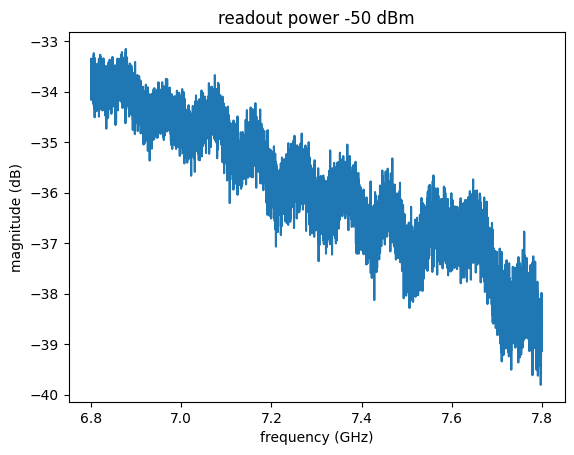

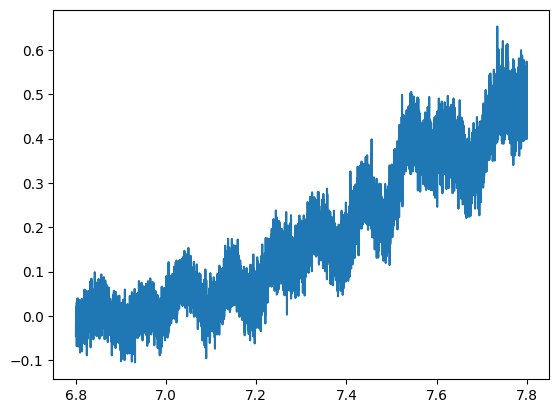

(10001,) (10001,)


In [99]:
num_freqs = 10001

start = 6.8; stop = 7.7; step = 1
#start = 7.6; stop = 7.8; step = 0.2



# x = RF_switch.RC2SP4TA18Controller(host='192.168.137.132')
# x.connect()
channel_dict = {1:'C5', 2:'C6', 3:'C8', 4:'C10'}

for i in range(1):#range(4):
    # x.switch('A',i+1)
    # x.switch('B',i+1)
    time.sleep(1)
    current = start

    freq_all = np.array([])
    mag_all = np.array([])
    phase_all = np.array([]) 

    while current <= stop:
            
        RS.reset()
        settings = RS.trans_default_settings()
        settings['measurement'] = 'S43'
        settings['start_freq'] = (current)*1e9
        settings['stop_freq'] = (current + step)*1e9
        settings['RFpower'] = -50
        settings['ifBW'] = 10000
        settings['avg_time'] = 300
        # if RFpower < -30:
        #     settings['avg_time'] = 0.5 * (10 ** (-RFpower/10)) / (10 ** (30/10))  # Increase averaging time for lower powers

        settings['freq_points'] = num_freqs
        data2 = RS.trans_meas(settings)
        mag = np.array(eval(str(data2['mag'])))
        phase = np.array(eval(str(data2['phase'])))
        freq = np.array(eval(str(data2['xaxis'])))/1e9

        freq_all = np.concatenate((freq_all,freq))
        mag_all = np.concatenate((mag_all,mag))
        phase_all = np.concatenate((phase_all,phase))

        phase_all_plot = np.unwrap(phase_all/180*np.pi)
        phase_fit = np.polyfit(freq_all[:1000], phase_all_plot[:1000], 1)
        phase_all_plot = phase_all_plot - np.polyval(phase_fit, freq_all)

        current += step


        clear_output(wait=True)  # clears previous plot in the notebook cell
        print(f'Measured {current-start:.2f} GHz / {stop-start:.2f} GHz', end='\r')
        plt.plot(freq_all, mag_all)
        plt.xlabel('frequency (GHz)')
        plt.ylabel('magnitude (dB)')
        plt.title('readout power {} dBm'.format(settings['RFpower']))

        plt.figure()
        plt.plot(freq_all, phase_all_plot)
        
        plt.show()
        time.sleep(0.1)   
        # res_idx = np.argmin(abs(freq-6.9028))
        # plt.plot(freq_all,mag_all)
        # plt.plot(freq[res_idx],mag[res_idx],'ro')
        # plt.show()
        print(freq_all.shape, mag_all.shape)
    # pickle.dump((freq_all, mag_all, phase_all), open(f'C:/_Data/SMPD/2026_03_14/BFG_C{channel_dict[i+1]}.pkl', 'wb'))

In [69]:
fit_vals

(12.285003862578613,
 21402.29340745184,
 42446.25380479794,
 (0.0007589611226961868-0.0001252935646357292j),
 -0.33794854907822225,
 (71.07545442085274-0.16315550386394911j),
 44991.09340357143,
 5.613393693384064e-11,
 array([ 1.22850039e+01,  2.14022934e+04,  4.24462538e+04,  7.58961123e-04,
        -1.25293565e-04, -3.37948549e-01,  7.10754544e+01, -1.63155504e-01]))

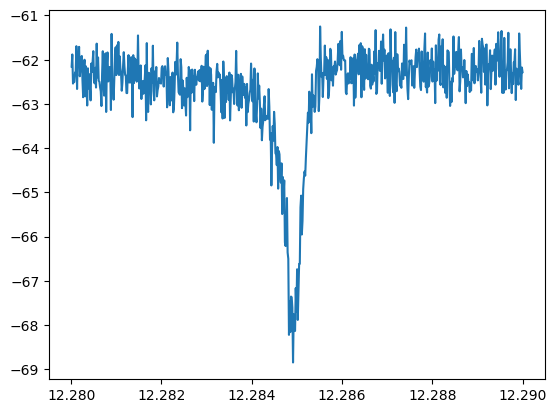

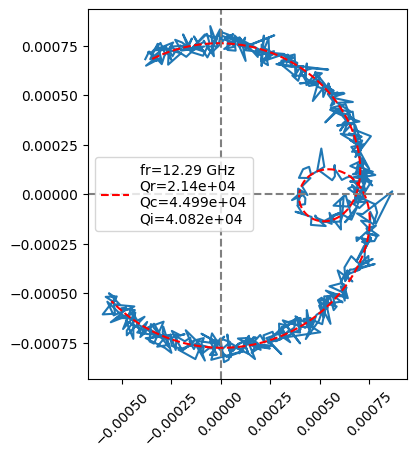

In [87]:
# look at a narrow region between 12.28 and 12.29 GHz
mask = (freq_all >= 12.28) & (freq_all <= 12.29)
plt.plot(freq_all[mask], mag_all[mask])

S21 = 10**(mag_all[mask]/20) * np.exp(1j * np.deg2rad(phase_all[mask]))

fit_vals = fitres.finefit(freq_all[mask], S21, [12.285])
fit_plot = fitres.resfunc3(freq_all[mask], *fit_vals[:-3])
Qi = 1/(1/fit_vals[1] - 1/fit_vals[-3])

plt.figure()
plt.plot(S21.real, S21.imag)
plt.plot(fit_plot.real, fit_plot.imag, 'r--',label='fr={:.4g} GHz\nQr={:.4g}\nQc={:.4g}\nQi={:.4g}'.format(fit_vals[0],fit_vals[1], fit_vals[-3], Qi))   
plt.axhline(0, color='gray', linestyle='--')
plt.axvline(0, color='gray', linestyle='--')
plt.xticks(rotation=45)
plt.gca().set_aspect('equal', adjustable='box')

plt.legend()

## zoom in on waste resonance

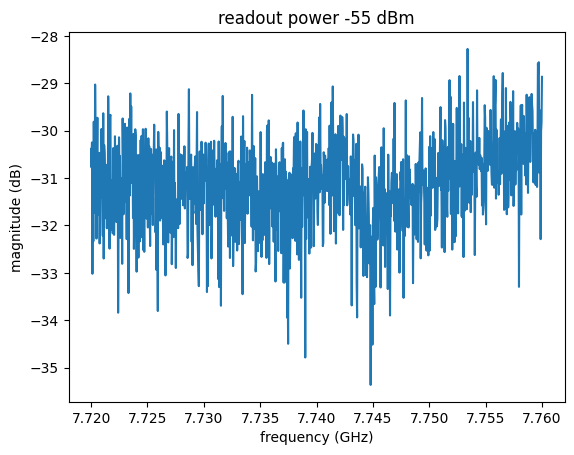

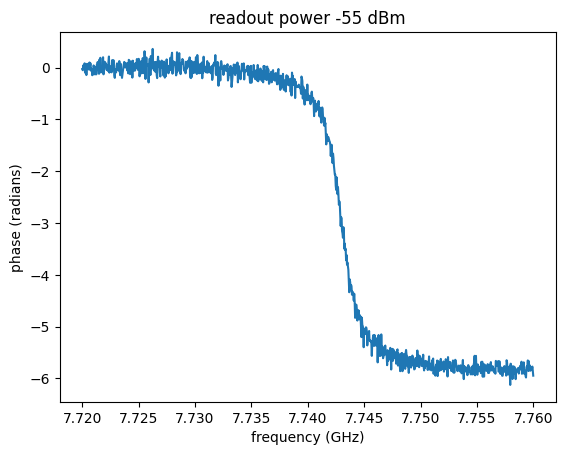

(1001,) (1001,)


In [80]:
num_freqs = 1001

start = 7.72; stop = 7.759; step = 0.04
# start = 7.6; stop = 7.8; step = 0.2

current = start

freq_all = np.array([])
mag_all = np.array([])
phase_all = np.array([]) 

while current <= stop:
        
    RS.reset()
    settings = RS.trans_default_settings()
    settings['measurement'] = 'S43'
    settings['start_freq'] = (current)*1e9
    settings['stop_freq'] = (current + step)*1e9
    settings['RFpower'] = -55
    settings['ifBW'] = 100000
    settings['avg_time'] = 10
    # if RFpower < -30:
    #     settings['avg_time'] = 0.5 * (10 ** (-RFpower/10)) / (10 ** (30/10))  # Increase averaging time for lower powers

    settings['freq_points'] = num_freqs
    data2 = RS.trans_meas(settings)
    mag = np.array(eval(str(data2['mag'])))
    phase = np.array(eval(str(data2['phase'])))
    freq = np.array(eval(str(data2['xaxis'])))/1e9

    freq_all = np.concatenate((freq_all,freq))
    mag_all = np.concatenate((mag_all,mag))
    phase_all = np.concatenate((phase_all,phase))

    phase_all_plot = np.unwrap(phase_all/180*np.pi)
    phase_fit = np.polyfit(freq_all[:num_freqs//10], phase_all_plot[:num_freqs//10], 1)
    phase_all_plot = phase_all_plot - np.polyval(phase_fit, freq_all)

    current += step


    clear_output(wait=True)  # clears previous plot in the notebook cell
    print(f'Measured {current-start:.2f} GHz / {stop-start:.2f} GHz', end='\r')
    plt.plot(freq_all, mag_all)
    plt.xlabel('frequency (GHz)')
    plt.ylabel('magnitude (dB)')
    plt.title('readout power {} dBm'.format(settings['RFpower']))

    plt.figure()
    plt.plot(freq_all, phase_all_plot)
    plt.xlabel('frequency (GHz)')
    plt.ylabel('phase (radians)')
    plt.title('readout power {} dBm'.format(settings['RFpower']))

    plt.show()
    time.sleep(0.1)   
    # res_idx = np.argmin(abs(freq-6.9028))
    # plt.plot(freq_all,mag_all)
    # plt.plot(freq[res_idx],mag[res_idx],'ro')
    # plt.show()
    print(freq_all.shape, mag_all.shape)
# pickle.dump((freq_all, mag_all, phase_all), open(f'C:/_Data/SMPD/2026_04_30_JPA/waste.pkl', 'wb'))

In [20]:
fit_result[0]

7.742945447449418

Resonance frequency: 7.742891 GHz


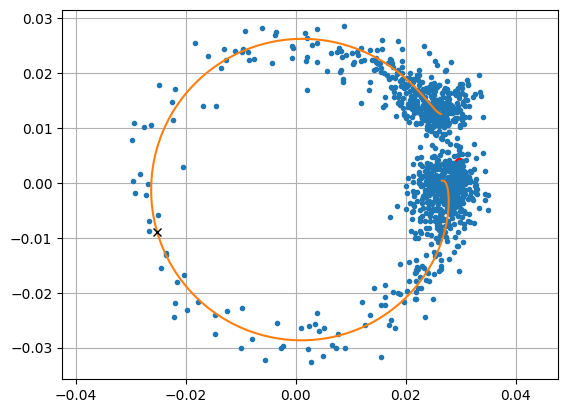

In [81]:
# load data 
# freq_all, mag_all, phase_all = pickle.load(open(f'C:/_Data/SMPD/2026_04_30_JPA/waste.pkl', 'rb'))

phase_all_plot = np.unwrap(phase_all/180*np.pi)
phase_fit = np.polyfit(freq_all[:len(freq_all)//10], phase_all_plot[:len(freq_all)//10], 1)
phase_all_plot = phase_all_plot - np.polyval(phase_fit, freq_all)

# convert mag_all and phase_all to complex S21
S21 = 10**(mag_all/20) * np.exp(1j * (phase_all_plot))

# find where the slope of the phase is maximum (approximate resonance frequency)
phase_slope = np.gradient(phase_all_plot, freq_all)
steepest_idx = np.argmax(np.abs(phase_slope))
resonance_freq = freq_all[steepest_idx]

# fit S21 using fitres.finefit
fit_result = fitres.finefit(freq_all, S21, [resonance_freq])
fit_plot = fitres.resfunc3(freq_all, *fit_result[:6])

S21_fit_fr = fitres.resfunc3(fit_result[0], *fit_result[:6])

plt.plot(S21.real, S21.imag, ls='', marker='.')
plt.plot(S21[steepest_idx].real, S21[steepest_idx].imag, 'ro',zorder=-100)
plt.plot(fit_plot.real, fit_plot.imag)
plt.plot(S21_fit_fr.real, S21_fit_fr.imag, 'kx')
plt.gca().set_aspect('equal', adjustable='datalim')
plt.grid(True)

waste_resonance = fit_result[0]

print(f"Resonance frequency: {fit_result[0]:.6f} GHz")

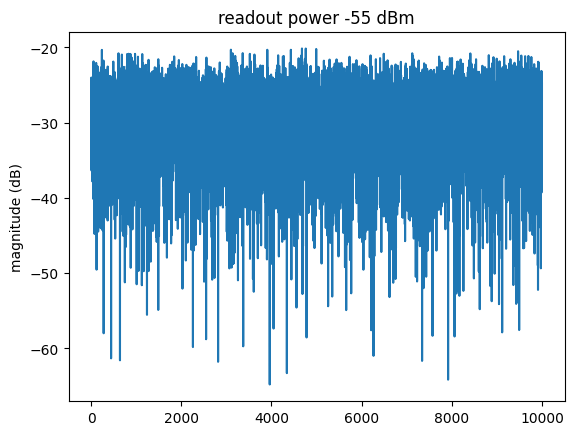

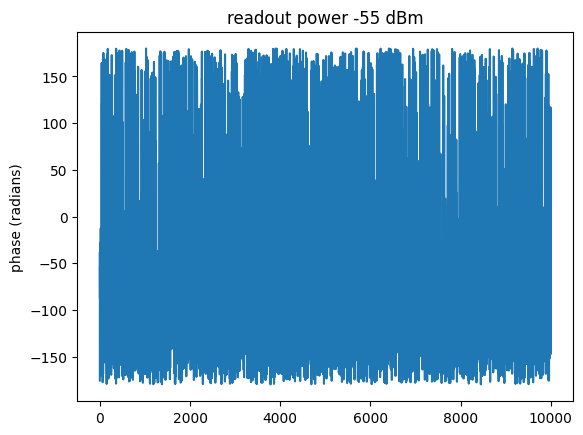

(10001,) (10001,)


In [ ]:
num_freqs = 10001



freq_all = np.array([])
mag_all = np.array([])
phase_all = np.array([]) 

        
RS.reset()
settings = RS.trans_default_settings()
settings['measurement'] = 'S43'
settings['start_freq'] = (fit_result[0])*1e9 
settings['stop_freq'] = (fit_result[0])*1e9
settings['RFpower'] = -55
settings['ifBW'] = 100000
settings['avg_time'] = 0

# if RFpower < -30:
#     settings['avg_time'] = 0.5 * (10 ** (-RFpower/10)) / (10 ** (30/10))  # Increase averaging time for lower powers

settings['freq_points'] = num_freqs
data2 = RS.trans_meas(settings)
mag = np.array(eval(str(data2['mag'])))
phase = np.array(eval(str(data2['phase'])))
freq = np.array(eval(str(data2['xaxis'])))/1e9

freq_all = np.concatenate((freq_all,freq))
mag_all = np.concatenate((mag_all,mag))
phase_all = np.concatenate((phase_all,phase))

# phase_all_plot = np.unwrap(phase_all/180*np.pi)
# phase_fit = np.polyfit(freq_all[:num_freqs//10], phase_all_plot[:num_freqs//10], 1)
# phase_all_plot = phase_all_plot - np.polyval(phase_fit, freq_all)


print(f'Measured {current-start:.2f} GHz / {stop-start:.2f} GHz', end='\r')
plt.plot(mag_all)
plt.ylabel('magnitude (dB)')
plt.title('readout power {} dBm'.format(settings['RFpower']))

plt.figure()
plt.plot(phase_all)
plt.ylabel('phase (radians)')
plt.title('readout power {} dBm'.format(settings['RFpower']))

plt.show()
time.sleep(0.1)   
# res_idx = np.argmin(abs(freq-6.9028))
# plt.plot(freq_all,mag_all)
# plt.plot(freq[res_idx],mag[res_idx],'ro')
# plt.show()
print(freq_all.shape, mag_all.shape)

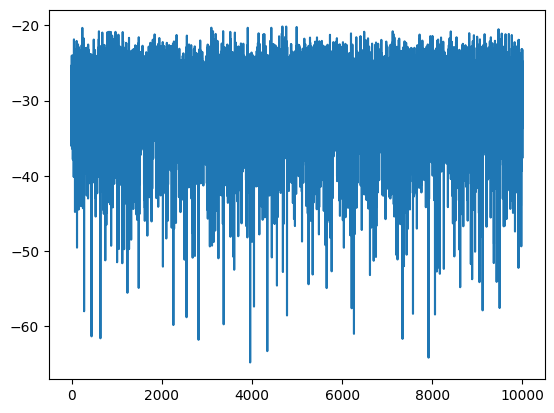

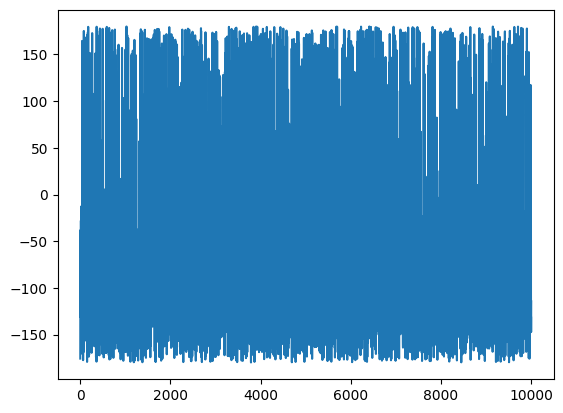

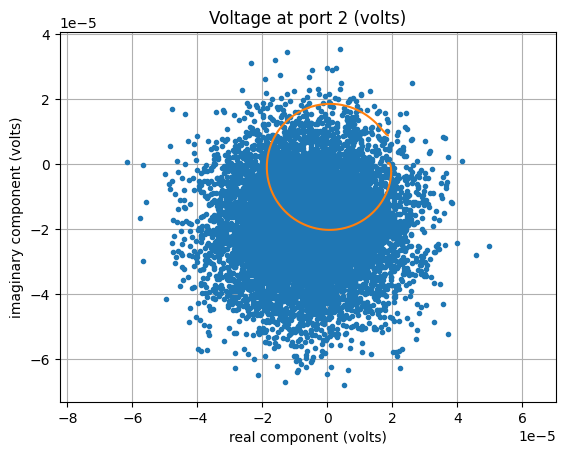

In [84]:
plt.plot(mag_all)

plt.figure()
plt.plot(phase_all)

plt.figure()
# convert -50 dBm into a voltage amplitude (assuming 50 ohm system)
V_amplitude = 10**((-50-30)/20) * np.sqrt(50)  # Convert dBm to voltage amplitude
S21 = 10**(mag_all/20) * np.exp(1j * (phase_all)/180*np.pi) * V_amplitude  # Scale by the voltage amplitude
plt.plot(S21.real, S21.imag, ls='', marker='.')
plt.plot(fit_plot.real*V_amplitude, fit_plot.imag*V_amplitude, ls='-', marker='')
plt.title('Voltage at port 2 (volts)')
plt.xlabel('real component (volts)')
plt.ylabel('imaginary component (volts)')
plt.gca().set_aspect('equal', adjustable='datalim')
plt.grid(True)

In [70]:
fit_result[5]

(-0.02338461487727011+0.48012035037400225j)

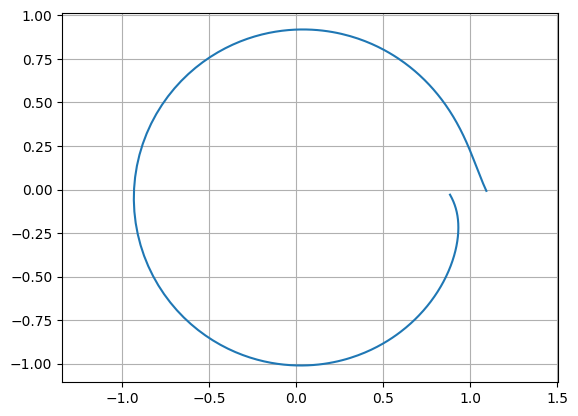

In [77]:
fr = fit_result[0]
Qr = fit_result[1]
Qc_hat_mag = fit_result[2]
a = fit_result[3]
phi0 = fit_result[4]
tau = fit_result[5]

def rotate_to_ideal(f,z,fr,a,tau,phi0):
    return 1 - (1 - z / (a*np.exp(1j*phi0)*np.exp(1j*2*np.pi*(f-fr)*tau))) * np.cos(phi0)

fit_plot_ideal = rotate_to_ideal(freq_all,fit_plot,fr,a,tau,phi0)
plt.figure()
plt.plot(fit_plot_ideal.real, fit_plot_ideal.imag, ls='-', marker='')
plt.gca().set_aspect('equal', adjustable='datalim')
plt.grid(True)

Text(0.5, 1.0, 'PSD of imaginary part of S21')

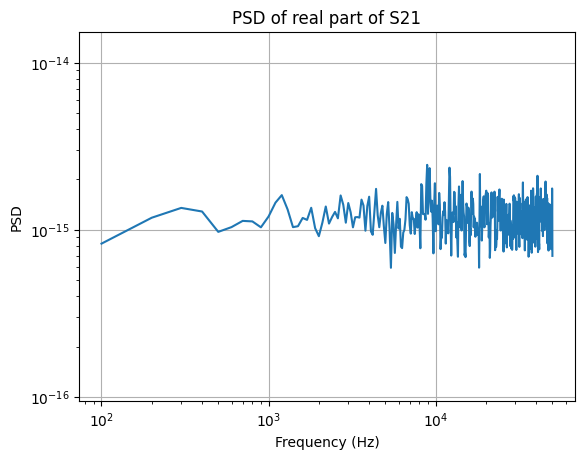

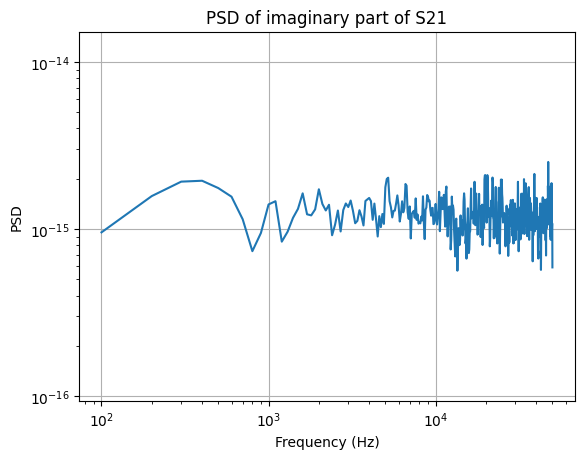

In [64]:
# make PSDs of S21 in the real and imaginary directions 
# use welch to compute the PSDs, with a sampling frequency equal to the IFBW
import scipy.signal
f_real, Pxx_real = scipy.signal.welch(S21.real, fs=100000, nperseg=1000)
f_imag, Pxx_imag = scipy.signal.welch(S21.imag, fs=100000, nperseg=1000)

plt.figure()
plt.loglog(f_real[f_real>0], Pxx_real[f_real>0])
plt.title('PSD of real part of S21')
plt.xlabel('Frequency (Hz)')
plt.ylabel('PSD')   
plt.gca().set_aspect('equal', adjustable='datalim')
plt.grid(True)
plt.figure()
plt.loglog(f_imag[f_imag>0], Pxx_imag[f_imag>0])
plt.xlabel('Frequency (Hz)')
plt.ylabel('PSD')
plt.gca().set_aspect('equal', adjustable='datalim')
plt.grid(True)
plt.title('PSD of imaginary part of S21')

# JPA gain measurement

In [11]:
data_dir = f'C:/_Data/SMPD/2026_05_21_JPA/'
image_dir = f'{data_dir}/images/'
if not os.path.exists(image_dir):
    os.makedirs(image_dir)

## measure waste baseline

Measure the waste resonator with VNA with JPA off. This is to set the baseline for the following gain measurement. **num_freqs, freq range have to be the same as in the gain scans.**

In [22]:
os.path.join(data_dir, set_name)

'C:/_Data/SMPD/2026_05_21_JPA/waste_baseline_0521_run2'

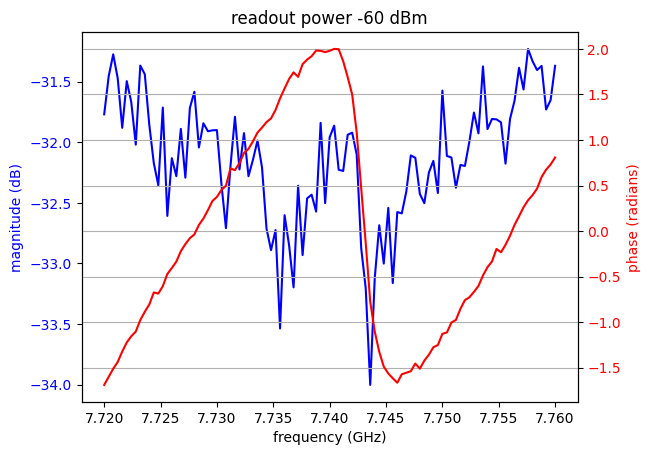

<Figure size 640x480 with 0 Axes>

In [23]:
set_name = f'waste_baseline_0521_run2.pkl'
file_name = os.path.join(data_dir, set_name)

num_freqs = 101
start = 7.72; stop = 7.759; step = 0.04

current = start

freq_all = np.array([])
mag_all = np.array([])
phase_all = np.array([]) 

while current <= stop:
        
    RS.reset()
    settings = RS.trans_default_settings()
    settings['measurement'] = 'S43'
    settings['start_freq'] = (current)*1e9
    settings['stop_freq'] = (current + step)*1e9
    settings['RFpower'] = -60
    settings['ifBW'] = 10000
    settings['avg_time'] = 50
    # if RFpower < -30:
    #     settings['avg_time'] = 0.5 * (10 ** (-RFpower/10)) / (10 ** (30/10))  # Increase averaging time for lower powers

    settings['freq_points'] = num_freqs
    data2 = RS.trans_meas(settings)
    mag = np.array(eval(str(data2['mag'])))
    phase = np.array(eval(str(data2['phase'])))
    freq = np.array(eval(str(data2['xaxis'])))/1e9

    freq_all = np.concatenate((freq_all,freq))
    mag_all = np.concatenate((mag_all,mag))
    phase_all = np.concatenate((phase_all,phase))

    phase_all_plot = np.unwrap(phase_all/180*np.pi)
    phase_fit = np.polyfit(freq_all[:1000], phase_all_plot[:1000], 1)
    phase_all_plot = phase_all_plot - np.polyval(phase_fit, freq_all)

    current += step

    clear_output(wait=True)  # clears previous plot in the notebook cell
    print(f'Measured {current-start:.2f} GHz / {stop-start:.2f} GHz', end='\r')
    time.sleep(0.1) 

pickle.dump((freq_all, mag_all, phase_all), open(file_name, 'wb'))

## plot mag and phase on the same figure with two y-axes
fig, ax1 = plt.subplots()
ax1.plot(freq_all, mag_all, 'b-')
ax1.set_xlabel('frequency (GHz)')
ax1.set_ylabel('magnitude (dB)', color='b')
ax1.tick_params(axis='y', labelcolor='b')
ax2 = ax1.twinx()
ax2.plot(freq_all, phase_all_plot, 'r-')
ax2.set_ylabel('phase (radians)', color='r')
ax2.tick_params(axis='y', labelcolor='r')
plt.title('readout power {} dBm'.format(settings['RFpower']))
plt.grid(True)
plt.show()
plt.savefig(os.path.join(image_dir, f'{set_name}.png'), dpi=300, bbox_inches='tight')

## scan over pump power and dc bias

In [51]:
SC = SignalCore(name='SC',address='100026C4')


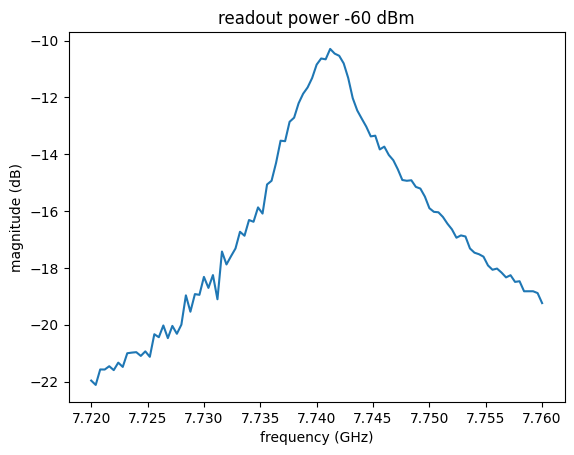

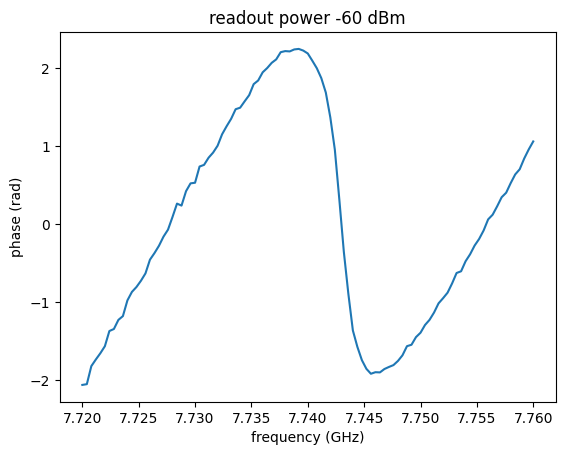

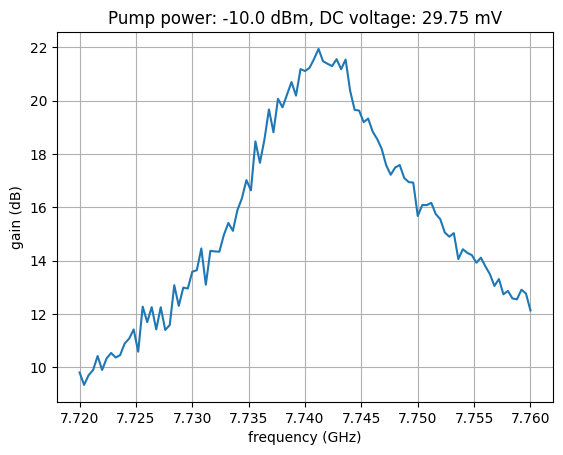

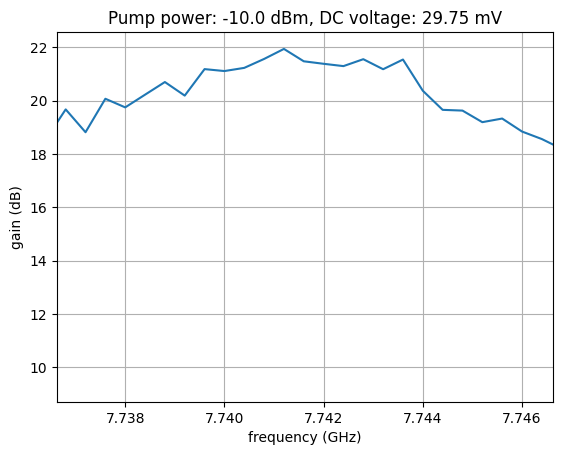

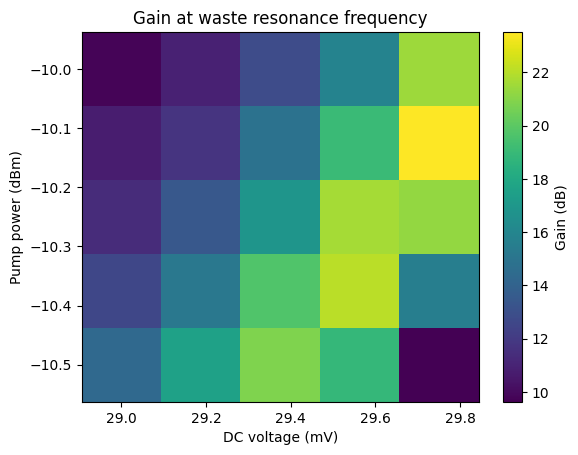

SC100026C4 : Set output state to False


0

In [52]:
num_freqs = 101
waste_resonance = 7.7416254

start = 7.72; stop = 7.759; step = 0.04
# start = 7.6; stop = 7.8; step = 0.2

pump_powers = np.linspace(-10.5,-10,5)
# pump_powers = [10.25]
num_pump_powers = len(pump_powers)
dc_voltages = np.linspace(29,29.75,5)
# dc_voltages = [29.62]
num_dc_voltages = len(dc_voltages)

gain_data = np.zeros((num_pump_powers, num_dc_voltages, num_freqs))

for i, pump_power in enumerate(pump_powers):
    SC.set_power(pump_power)   
    params = SC.get_rf_parameters()
    # print(dir(params))
    print(params.rf1_freq, params.rf_level)

    pump_power_str = f"{params.rf_level:.1f}".replace('.', 'p')

    SC.set_output_state(enable=True)
    # status = SC.get_device_status()
    # print(status.operate_status.rf1_out_enable)

    # store the gain data in a three dimensional array with dimensions (num_pump_powers, num_dc_voltages, num_freqs)





    for j, dc_voltage in enumerate(dc_voltages):
        print('setting DC voltage to {} mV'.format(dc_voltage))
        b.set_voltage_mV(CH, voltage_mv=dc_voltage)
        b.enable_output(CH)    

        freq_all = np.array([])
        mag_all = np.array([])
        phase_all = np.array([]) 

        current = start
        while current <= stop:
                
            RS.reset()
            settings = RS.trans_default_settings()
            settings['measurement'] = 'S43'
            settings['start_freq'] = (current)*1e9
            settings['stop_freq'] = (current + step)*1e9
            settings['RFpower'] = -60
            settings['ifBW'] = 10000
            settings['avg_time'] = 10
            # if RFpower < -30:
            #     settings['avg_time'] = 0.5 * (10 ** (-RFpower/10)) / (10 ** (30/10))  # Increase averaging time for lower powers

            settings['freq_points'] = num_freqs
            data2 = RS.trans_meas(settings)
            mag = np.array(eval(str(data2['mag'])))
            phase = np.array(eval(str(data2['phase'])))
            freq = np.array(eval(str(data2['xaxis'])))/1e9

            freq_all = np.concatenate((freq_all,freq))
            mag_all = np.concatenate((mag_all,mag))
            phase_all = np.concatenate((phase_all,phase))

            phase_all_plot = np.unwrap(phase_all/180*np.pi)
            phase_fit = np.polyfit(freq_all[:1000], phase_all_plot[:1000], 1)
            phase_all_plot = phase_all_plot - np.polyval(phase_fit, freq_all)

            current += step


            # clear_output(wait=True)  # clears previous plot in the notebook cell
            print(f'Measured {current-start:.2f} GHz / {stop-start:.2f} GHz', end='\r')
            plt.figure()
            plt.plot(freq_all, mag_all)
            plt.xlabel('frequency (GHz)')
            plt.ylabel('magnitude (dB)')
            plt.title('readout power {} dBm'.format(settings['RFpower']))

            plt.figure()
            plt.plot(freq_all, phase_all_plot)
            plt.xlabel('frequency (GHz)')
            plt.ylabel('phase (rad)')
            plt.title('readout power {} dBm'.format(settings['RFpower']))

            time.sleep(0.1)   
            # res_idx = np.argmin(abs(freq-6.9028))
            # plt.plot(freq_all,mag_all)
            # plt.plot(freq[res_idx],mag[res_idx],'ro')
            # plt.show()
            print(freq_all.shape, mag_all.shape)


        # pickle.dump((freq_all, mag_all, phase_all), open(f'{data_dir}/waste_pump_{pump_power_str}_{dc_voltage:.1f}mV.pkl', 'wb'))

        # load waste_baseline.pkl and compute the gain
        freq_baseline, mag_baseline, phase_baseline = pickle.load(open(f'{data_dir}/waste_baseline_0521_run2.pkl', 'rb'))
        S21_baseline = 10**(mag_baseline/20) * np.exp(1j * (phase_baseline/180*np.pi))

        S21_pump_on = 10**(mag_all/20) * np.exp(1j * (phase_all/180*np.pi))

        # Compute the gain
        S21_gain = S21_pump_on / S21_baseline
        clear_output(wait=True)
        plt.figure()
        plt.plot(freq_all, 20*np.log10(np.abs(S21_gain)))
        plt.xlabel('frequency (GHz)')
        plt.ylabel('gain (dB)')
        plt.title('Pump power: {:<.1f} dBm, DC voltage: {} mV'.format(pump_power, dc_voltage))
        plt.grid(True)

        plt.figure()
        plt.plot(freq_all, 20*np.log10(np.abs(S21_gain)))
        plt.xlabel('frequency (GHz)')
        plt.ylabel('gain (dB)')
        plt.title('Pump power: {:<.1f} dBm, DC voltage: {} mV'.format(pump_power, dc_voltage))
        plt.xlim(waste_resonance - 0.005, waste_resonance + 0.005)
        plt.grid(True)


        

        gain_data[i, j, :] = 20*np.log10(np.abs(S21_gain))

        # take an average of the gain data in a 0.5 MHz window around the waste resonance frequency
        freq_window = 0.5e6/1e9  # 0.5 MHz

        # Find the indices within the frequency window
        freq_indices = np.where((freq_all >= waste_resonance - freq_window/2) & (freq_all <= waste_resonance + freq_window/2))[0]

        # Compute the average gain within the frequency window
        gain_data_at_resonance = np.mean(gain_data[:,:,freq_indices], axis=2)

        plt.figure()
        plt.pcolormesh(dc_voltages, pump_powers, gain_data_at_resonance, shading='auto')
        plt.xlabel('DC voltage (mV)')
        plt.ylabel('Pump power (dBm)')
        plt.title('Gain at waste resonance frequency')
        plt.colorbar(label='Gain (dB)')
        plt.show()
        


pickle.dump(gain_data, open(f'{data_dir}/gain_data_0521_run2.pkl', 'wb'))

SC.set_output_state(enable=False)
SC.close_device()


In [53]:
# find the maximum gain and the corresponding pump power and DC voltage
max_gain = np.max(gain_data)
max_gain_idx = np.unravel_index(np.argmax(gain_data), gain_data.shape)
optimal_pump_power = pump_powers[max_gain_idx[0]]
optimal_dc_voltage = dc_voltages[max_gain_idx[1]]
print(f'Maximum gain: {max_gain:.2f} dB at pump power {optimal_pump_power:.2f} dBm and DC voltage {optimal_dc_voltage:.2f} mV')

Maximum gain: 24.00 dB at pump power -10.12 dBm and DC voltage 29.75 mV


In [4]:
b.set_voltage_mV(CH, 0)
b.disable_output(CH)

 to IP: ('192.168.137.85', 23)
Received: 0



7.7416254


TypeError: Dimensions of C (5, 5) should be one smaller than X(10) and Y(10) while using shading='flat' see help(pcolormesh)

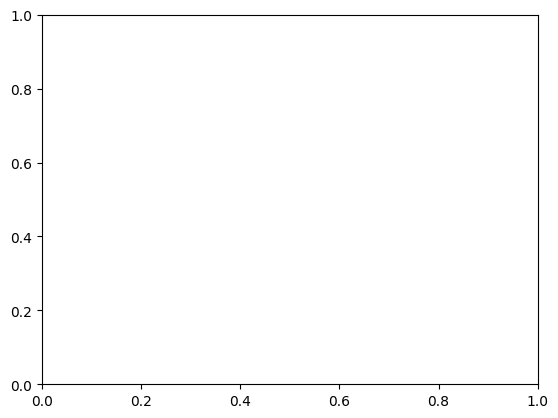

In [33]:
#pump_powers = np.linspace(-15,-9,25)
#dc_voltages = np.linspace(18,28,41)
#pump_powers = np.linspace(-12,-9,5)
#dc_voltages = np.linspace(24,28,5)
pump_powers = np.linspace(-11.5,-9.5,10)
dc_voltages = np.linspace(23.5,26.5,10)
freq_all, _, _ = pickle.load(open('C:/_Data/SMPD/2026_05_21_JPA/waste_baseline_0521_run2.pkl', 'rb'))
print(waste_resonance)

# load gain data and plot the gain at the waste resonance frequency as a function of pump power and DC voltage
#gain_data_load = pickle.load(open(f'C:/_Data/SMPD/2026_04_30_JPA/gain_data.pkl', 'rb'))
gain_data_load = pickle.load(open(f'C:/_Data/SMPD/2026_05_21_JPA/gain_data_0521_run2.pkl', 'rb'))

# take an average of the gain data in a 0.5 MHz window around the waste resonance frequency
freq_window = 0.5e6/1e9  # 0.5 MHz

# Find the indices within the frequency window
freq_indices = np.where((freq_all >= waste_resonance - freq_window/2) & (freq_all <= waste_resonance + freq_window/2))[0]

# Compute the average gain within the frequency window
gain_data_at_resonance = np.mean(gain_data_load[:,:,freq_indices], axis=2)

plt.pcolormesh(dc_voltages, pump_powers, gain_data_at_resonance, shading='auto',vmin=0)
plt.xlabel('DC voltage (mV)')
plt.ylabel('Pump power at 7.740 GHz (dBm)')
plt.title(f'inferred JPA resonance from DC voltage (GHz)',fontsize=10)
plt.colorbar(label=f'Gain at {waste_resonance:.6f} GHz (dB)')

#plt.xlim(24, 28)
#plt.ylim(-12, -9)

# put tick marks at the top that correspond to the JPA frequency at each pump power, which can be computed using the fit result from the waste resonance frequency and the pump power
# the JPA frequency can just be interpolated from dc_powers and frs
# get current xticks
xticks = plt.gca().get_xticks()
xticks = xticks[1:-1]
ticks_desired = [7.75, 7.8, 7.85]
tick_idcs = np.linspace(1, len(dc_powers),6)
jpa_frequencies = np.interp(xticks, dc_powers, frs)
tick_locations = np.interp(ticks_desired, jpa_frequencies, tick_idcs)

# print(jpa_frequencies)
print(tick_locations)
# put tick marks at the top at the same location as the bottom xticks
plt.gca().twiny().set_xticks(tick_locations,labels=ticks_desired)
# y().set_xlabel('JPA resonance (GHz)')
# plt.gca().twiny().set_xticklabels(ticks_desired)
# plt.gca().twiny().set_xlabel('JPA frequency (GHz)')

# find the maximum gain and the corresponding pump power and DC voltage
max_gain = np.max(gain_data_at_resonance)
max_gain_idx = np.unravel_index(np.argmax(gain_data_at_resonance), gain_data_at_resonance.shape)
optimal_pump_power = pump_powers[max_gain_idx[0]]
optimal_dc_voltage = dc_voltages[max_gain_idx[1]]
plt.figure()
plt.plot(freq_all, gain_data_load[max_gain_idx[0], max_gain_idx[1], :])
plt.xlabel('frequency (GHz)')
plt.ylabel('gain (dB)')
plt.title('optimal pump power: {:<.1f} dBm, optimal DC voltage: {} mV'.format(optimal_pump_power, optimal_dc_voltage))

plt.figure()
plt.plot(freq_all, gain_data_load[max_gain_idx[0], max_gain_idx[1], :])
plt.xlim(waste_resonance - 0.005, waste_resonance + 0.005)
plt.xlabel('frequency (GHz)')
plt.ylabel('gain (dB)')
plt.title('optimal pump power: {:<.1f} dBm, optimal DC voltage: {} mV'.format(optimal_pump_power, optimal_dc_voltage))

# also show the gain at -11.5 dBm pump power and 25 mV DC voltage
pump_power_11_5_idx = np.argmin(np.abs(pump_powers - (-11.5)))
dc_voltage_25_idx = np.argmin(np.abs(dc_voltages - 25))
plt.figure()
plt.plot(freq_all, gain_data_load[pump_power_11_5_idx, dc_voltage_25_idx, :])
# plt.xlim(waste_resonance - 0.005, waste_resonance + 0.005)
plt.xlabel('frequency (GHz)')
plt.ylabel('gain (dB)')
plt.title('pump power: {:<.1f} dBm, DC voltage: {} mV'.format(pump_powers[pump_power_11_5_idx], dc_voltages[dc_voltage_25_idx]))


plt.figure()
plt.plot(freq_all, gain_data_load[pump_power_11_5_idx, dc_voltage_25_idx, :])
plt.xlim(waste_resonance - 0.005, waste_resonance + 0.005)
plt.xlabel('frequency (GHz)')
plt.ylabel('gain (dB)')
plt.title('pump power: {:<.1f} dBm, DC voltage: {} mV'.format(pump_powers[pump_power_11_5_idx], dc_voltages[dc_voltage_25_idx]))


In [31]:
print(np.shape(dc_voltages))
print(np.shape(pump_powers))
print(np.shape(gain_data_at_resonance))

(1,)
(1,)
(25, 41)


BFG_C10.pkl
BFG_C11.pkl
BFG_C5.pkl
BFG_C6.pkl
BFG_C8.pkl


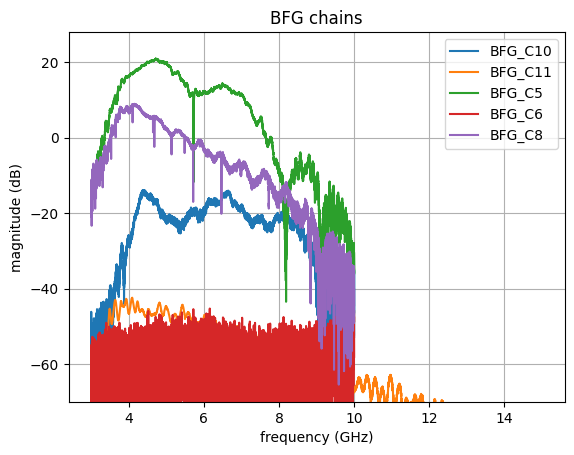

In [47]:
data_dir = 'C:/_Data/SMPD/2026_03_14'
for file in os.listdir(data_dir):
    if file.endswith('.pkl') and file.startswith('BFG'):
        print(file)
        freq_all, mag_all, phase_all = pickle.load(open(os.path.join(data_dir, file), 'rb'))
        plt.plot(freq_all, mag_all,label=file.split('/')[-1].split('.')[0])
        
plt.xlabel('frequency (GHz)')
plt.ylabel('magnitude (dB)')
plt.title('BFG chains')
plt.legend()
plt.ylim(bottom=-70)
# plt.xlim(left=6.5,right=8)
plt.grid(True)

C10_circulator_to_output.pkl
C11_circulator_to_output.pkl
C5_circulator_to_output.pkl
C6_circulator_to_output.pkl
C8_circulator_to_output.pkl
C9_circulator_to_output.pkl


(-100.0, 54.80822177935)

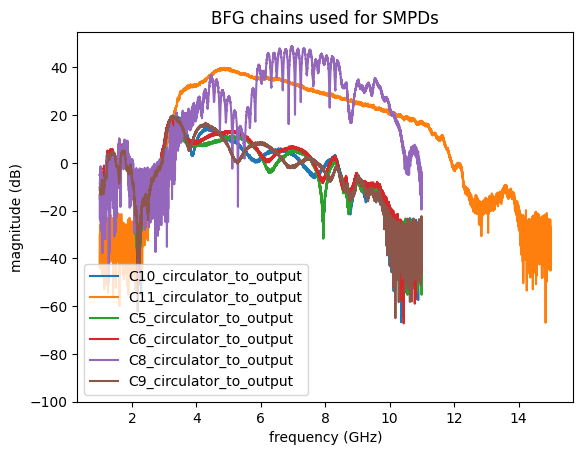

In [140]:
data_dir = 'C:/_Data/SMPD/2026_02_06/circulator_reflection_port'
for file in os.listdir(data_dir):
    if file.endswith('.pkl') :
        print(file)
        freq_all, mag_all, phase_all = pickle.load(open(os.path.join(data_dir, file), 'rb'))
        plt.plot(freq_all, mag_all,label=file.split('/')[-1].split('.')[0])
        
plt.xlabel('frequency (GHz)')
plt.ylabel('magnitude (dB)')
plt.title('BFG chains used for SMPDs')
plt.legend()
plt.ylim(bottom=-100)

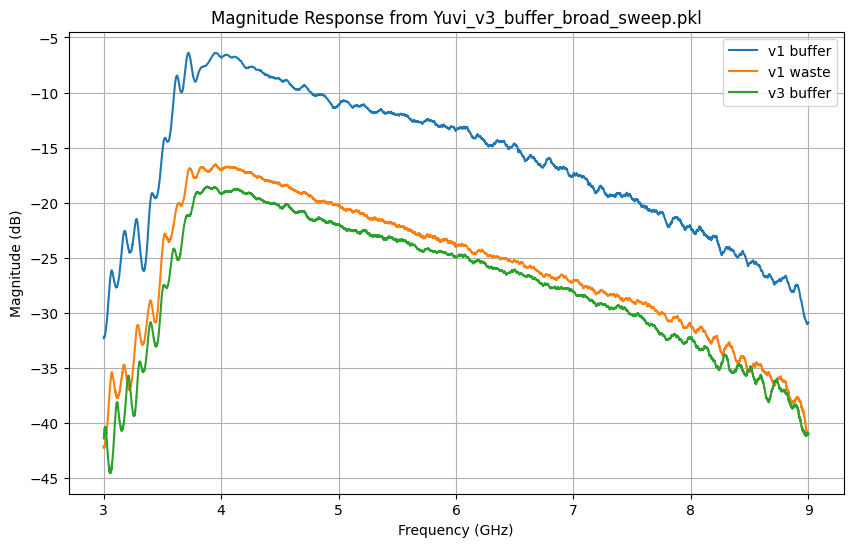

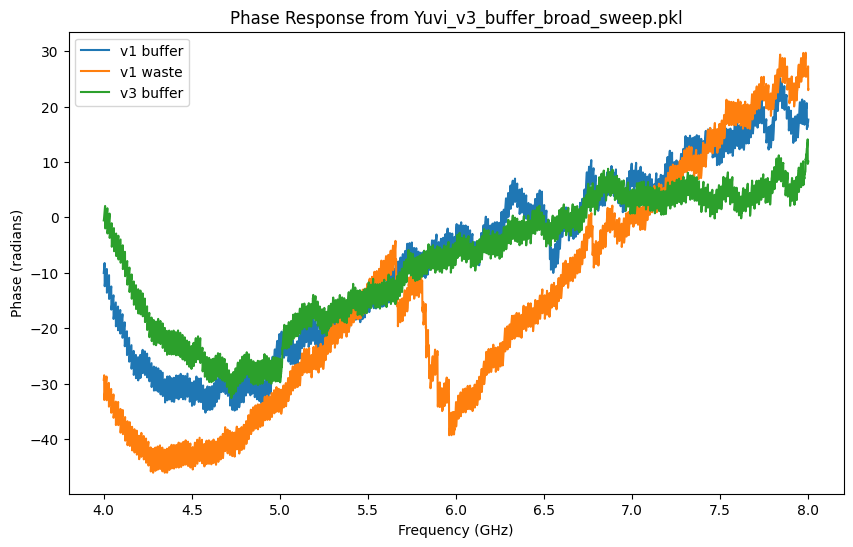

In [34]:
data_dir = 'C:/_Data/SMPD/2026_01_16/'
fig1,ax1 = plt.subplots(figsize=(10,6), num=1)
fig2,ax2 = plt.subplots(figsize=(10,6), num=2)
for file in os.listdir(data_dir):
    if file.endswith('.pkl') and not 'v3_waste' in file:
        file_id = file.split('_')[1] +' ' + file.split('_')[2]
        freq_all, mag_all, phase_all = pickle.load(open(os.path.join(data_dir, file), 'rb'))
        # plt.figure(num=1)
        ax1.plot(freq_all, mag_all,label=file_id)
        ax1.set_xlabel('Frequency (GHz)')
        ax1.set_ylabel('Magnitude (dB)')
        ax1.set_title(f'Magnitude Response from {file}')
        ax1.legend()
        ax1.grid(True)
    
        # plt.figure(num=2)
        phase_all_plot = np.unwrap(phase_all)
        phase_fit = np.polyfit(freq_all, phase_all_plot, 1)
        phase_all_plot = phase_all_plot - np.polyval(phase_fit, freq_all)
        freq_conditional = (freq_all>4)&(freq_all<8)
        ax2.plot(freq_all[freq_conditional], phase_all_plot[freq_conditional],label=file_id)
        ax2.set_xlabel('Frequency (GHz)')
        ax2.set_ylabel('Phase (radians)')
        ax2.set_title(f'Phase Response from {file}')
        ax2.legend()
        # plt.tight_layout()
        # plt.show()

## DC bias scan

In [6]:
np.arange(5,11,1)

array([ 5,  6,  7,  8,  9, 10])

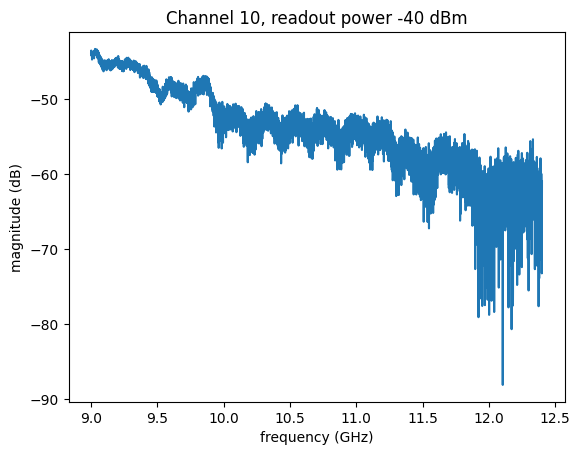

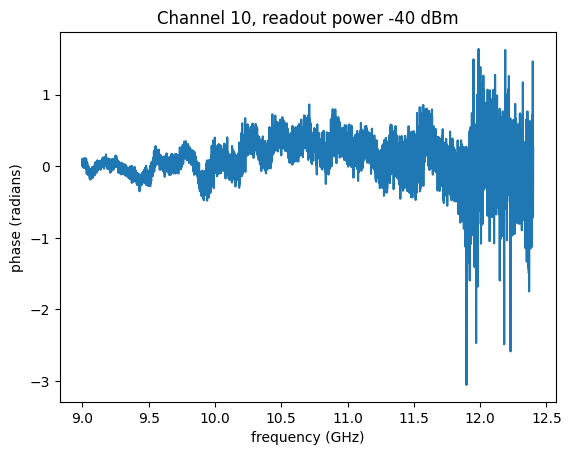

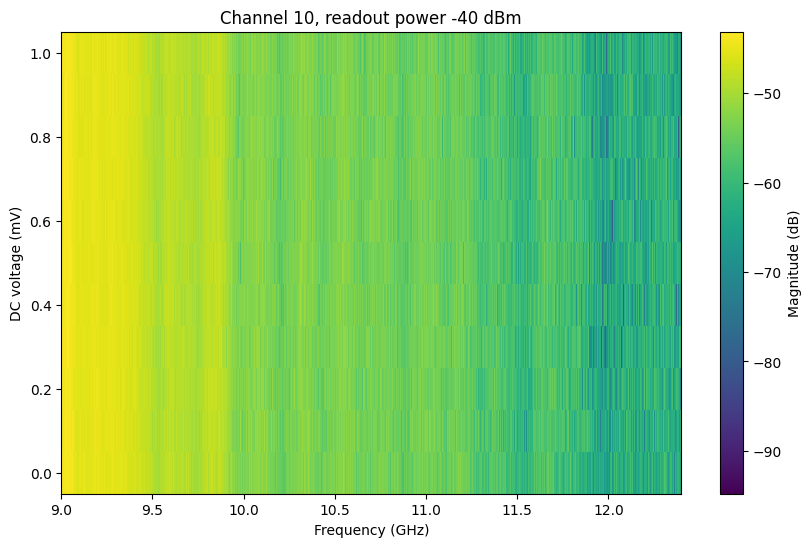

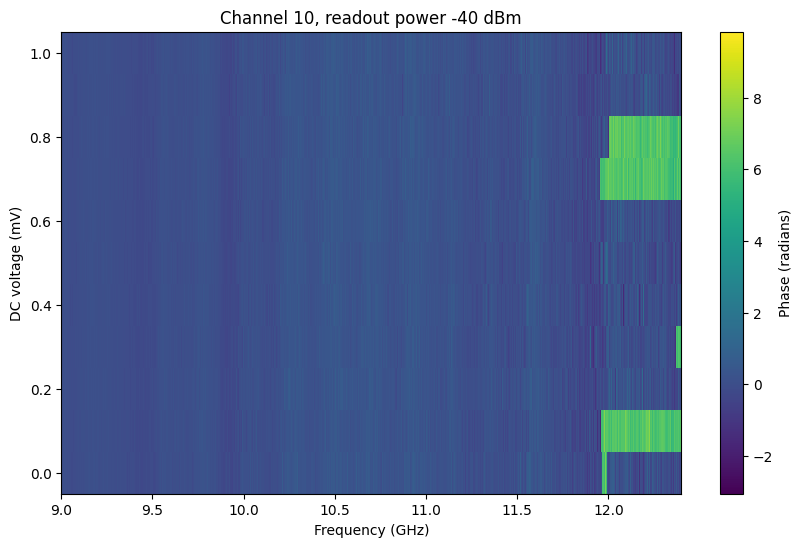

 to IP: ('192.168.137.217', 23)
Received: 0



In [6]:
# loop over CH from 5 to 10, and for each CH, loop over DC power from -0.5 mV to 5 mV in 21 steps, and for each DC power, measure the S43 parameter using the RS and store the magnitude and phase in a 2D array with dimensions (num_dc_powers, num_freqs)
for CH in np.arange(5,11,1):
    bias.set_voltage_mV(CH, 0)
    bias.enable_output(CH)
    num_freqs = 10001
    num_dc_powers = 11

    freq_array = np.zeros((num_dc_powers, num_freqs))
    mag_array = np.zeros((num_dc_powers, num_freqs))
    phase_array = np.zeros((num_dc_powers, num_freqs))


    dc_powers = np.linspace(0,1,num_dc_powers)
    for i, dc_power in enumerate(dc_powers):
        print('set DC power to {} mV'.format(dc_power))
        bias.set_voltage_mV(CH,dc_power)
        bias.enable_output(CH)
        time.sleep(0.1)
        start = 9 ; stop = 12.39; step = 3.4   
        #start = 7.6; stop = 7.8; step = 0.2

        current = start
        freq_all = np.array([])
        mag_all = np.array([])
        phase_all = np.array([]) 


        while current < stop:
                
            RS.reset()
            settings = RS.trans_default_settings()
            settings['measurement'] = 'S43'
            settings['start_freq'] = (current)*1e9
            settings['stop_freq'] = (current + step)*1e9
            settings['RFpower'] = -40
            settings['ifBW'] = 10000
            settings['avg_time'] = 360
            # if RFpower < -30:
            #     settings['avg_time'] = 0.5 * (10 ** (-RFpower/10)) / (10 ** (30/10))  # Increase averaging time for lower powers

            settings['freq_points'] = 10001
            data2 = RS.trans_meas(settings)
            mag = np.array(eval(str(data2['mag'])))
            phase = np.array(eval(str(data2['phase'])))
            freq = np.array(eval(str(data2['xaxis'])))/1e9

            freq_all = np.concatenate((freq_all,freq))
            mag_all = np.concatenate((mag_all,mag))
            phase_all = np.concatenate((phase_all,phase))

            phase_all_plot = np.unwrap(phase_all/180*np.pi)
            phase_fit = np.polyfit(freq_all[:1000], phase_all_plot[:1000], 1)
            phase_all_plot = phase_all_plot - np.polyval(phase_fit, freq_all)

            current += step

            if dc_power != dc_powers[0]:
                clear_output(wait=True)  # clears previous plot in the notebook cell
            print(f'Measured {current-start:.2f} GHz / {stop-start:.2f} GHz', end='\r')
            plt.plot(freq_all, mag_all)
            plt.xlabel('frequency (GHz)')
            plt.ylabel('magnitude (dB)')
            plt.title('Channel {}, readout power {} dBm'.format(CH, settings['RFpower']))

            plt.figure()
            plt.plot(freq_all, phase_all_plot)
            plt.xlabel('frequency (GHz)')
            plt.ylabel('phase (radians)')
            plt.title('Channel {}, readout power {} dBm'.format(CH, settings['RFpower']))



            # res_idx = np.argmin(abs(freq-6.9028))
            # plt.plot(freq_all,mag_all)
            # plt.plot(freq[res_idx],mag[res_idx],'ro')
            # plt.show()
        
        freq_array[i,:] = freq_all
        mag_array[i,:] = mag_all
        phase_array[i,:] = phase_all_plot

        plt.figure(figsize=(10,6)) 
        plt.pcolormesh(freq_array[0,:], dc_powers, mag_array[:,:], shading='auto')
        plt.colorbar(label='Magnitude (dB)')
        plt.ylabel('DC voltage (mV)')
        plt.xlabel('Frequency (GHz)')
        plt.title('Channel {}, readout power {} dBm'.format(CH, settings['RFpower']))
        plt.savefig('C:/_Data/SMPD/2026_05_25/tunable_resonator_higher_freq_CH{}_magnitude.png'.format(CH), dpi=300, bbox_inches='tight')


        plt.figure(figsize=(10,6)) 
        plt.pcolormesh(freq_array[0,:], dc_powers, phase_array[:,:], shading='auto')
        plt.colorbar(label='Phase (radians)')
        plt.ylabel('DC voltage (mV)')
        plt.xlabel('Frequency (GHz)')    
        plt.title('Channel {}, readout power {} dBm'.format(CH, settings['RFpower']))
        plt.savefig('C:/_Data/SMPD/2026_05_25/tunable_resonator_higher_freq_CH{}_phase.png'.format(CH), dpi=300, bbox_inches='tight')

        plt.show()
        time.sleep(0.1)   

    bias.set_voltage_mV(CH, 0)
    bias.disable_output(CH)

    pickle.dump((freq_array, mag_array, phase_array, dc_powers), open('C:/_Data/SMPD/2026_05_25/tunable_resonator_higher_freq_CH{}.pkl'.format(CH), 'wb'))


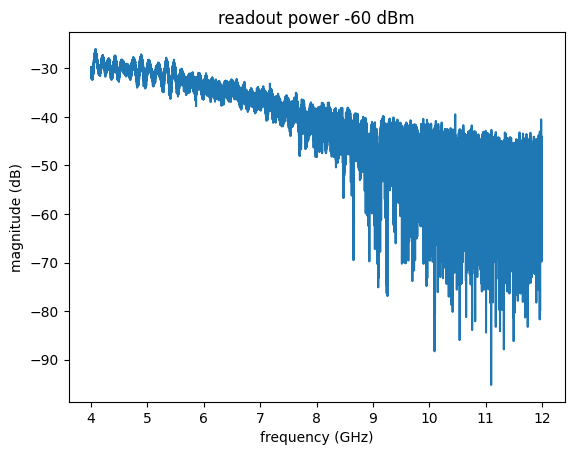

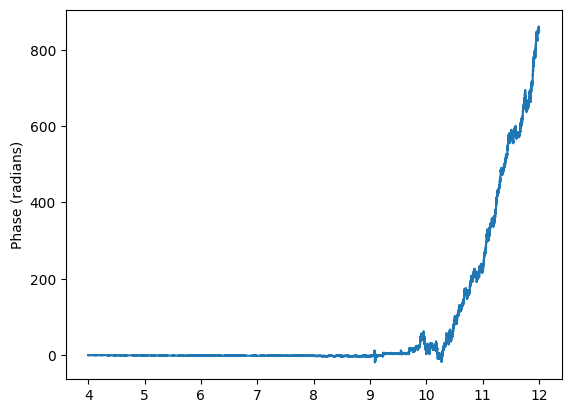

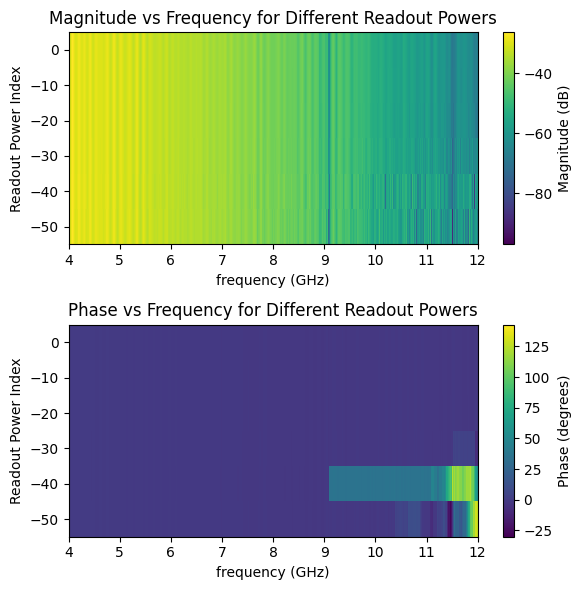

In [92]:
num_freqs = 10001*4

start = 4; stop = 11; step = 2
#start = 7.6; stop = 7.8; step = 0.2


current = start

#initialize array to store data over readout powers


RFpowers=   [0,-10,-20,-30, -40, -50, -60]

mag_pow_sweep = np.zeros((len(RFpowers), num_freqs))
phase_pow_sweep = np.zeros((len(RFpowers), num_freqs))
freq_pow_sweep = np.zeros((len(RFpowers), num_freqs))

# sweep over readout power
for iRFpower, RFpower in enumerate(RFpowers):

    freq_all = np.array([])
    mag_all = np.array([])
    phase_all = np.array([]) 

    while current <= stop:
            
        RS.reset()
        settings = RS.trans_default_settings()
        settings['measurement'] = 'S43'
        settings['start_freq'] = (current)*1e9
        settings['stop_freq'] = (current + step)*1e9
        settings['RFpower'] = RFpower
        settings['ifBW'] = 10000
        settings['avg_time'] = 50
        if RFpower < -40:
            settings['avg_time'] = 500
        # if RFpower < -30:
        #     settings['avg_time'] = 0.5 * (10 ** (-RFpower/10)) / (10 ** (30/10))  # Increase averaging time for lower powers

        settings['freq_points'] = 10001
        data2 = RS.trans_meas(settings)
        mag = np.array(eval(str(data2['mag'])))
        phase = np.array(eval(str(data2['phase'])))
        freq = np.array(eval(str(data2['xaxis'])))/1e9

        freq_all = np.concatenate((freq_all,freq))
        mag_all = np.concatenate((mag_all,mag))
        phase_all = np.concatenate((phase_all,phase))

        phase_all_plot = np.unwrap(phase_all/180*np.pi)
        phase_fit = np.polyfit(freq_all[:1000], phase_all_plot[:1000], 1)
        phase_all_plot = phase_all_plot - np.polyval(phase_fit, freq_all)

        current += step


        clear_output(wait=True)  # clears previous plot in the notebook cell
        print(f'Measured {current-start:.2f} GHz / {stop-start:.2f} GHz', end='\r')
        plt.plot(freq_all, mag_all)
        plt.xlabel('frequency (GHz)')
        plt.ylabel('magnitude (dB)')
        plt.title('readout power {} dBm'.format(settings['RFpower']))

        plt.figure()
        plt.plot(freq_all, phase_all_plot)
        plt.ylabel('Phase (radians)')
        plt.show()
        time.sleep(0.1)   
        # res_idx = np.argmin(abs(freq-6.9028))
        # plt.plot(freq_all,mag_all)
        # plt.plot(freq[res_idx],mag[res_idx],'ro')
        # plt.show()
    freq_pow_sweep[ iRFpower,:] = freq_all
    mag_pow_sweep[ iRFpower,:] = mag_all
    phase_pow_sweep[ iRFpower,:] = phase_all_plot
    
    current = start

# plot phase and magnitude vs frequency for all powers
plt.figure(figsize=(6, 6))
plt.subplot(2, 1, 1)
plt.pcolormesh(freq_pow_sweep[0,:], RFpowers[:-1], mag_pow_sweep[:-1,:], shading='auto')
plt.colorbar(label='Magnitude (dB)')
plt.ylabel('Readout Power Index')
plt.title('Magnitude vs Frequency for Different Readout Powers')
plt.xlabel('frequency (GHz)')

plt.subplot(2, 1, 2)
plt.pcolormesh(freq_pow_sweep[0,:], RFpowers[:-1], phase_pow_sweep[:-1,:], shading='auto')
plt.colorbar(label='Phase (degrees)')
plt.ylabel('Readout Power Index')
plt.title('Phase vs Frequency for Different Readout Powers')
plt.xlabel('frequency (GHz)')
plt.tight_layout()


pickle.dump((freq_pow_sweep, mag_pow_sweep, phase_pow_sweep,RFpowers), open(f'C:\\_Data\\SMPD\\2026_04_02_v3_buffer_search\\Yuvi_v3_buffer_power_sweep.pkl', 'wb'))

In [29]:
pickle.dump((freq_array, mag_array, phase_array), open('C:/_Data/SMPD/2026_03_14/Yuvi_v3_buffer_dc_sweep.pkl', 'wb'))

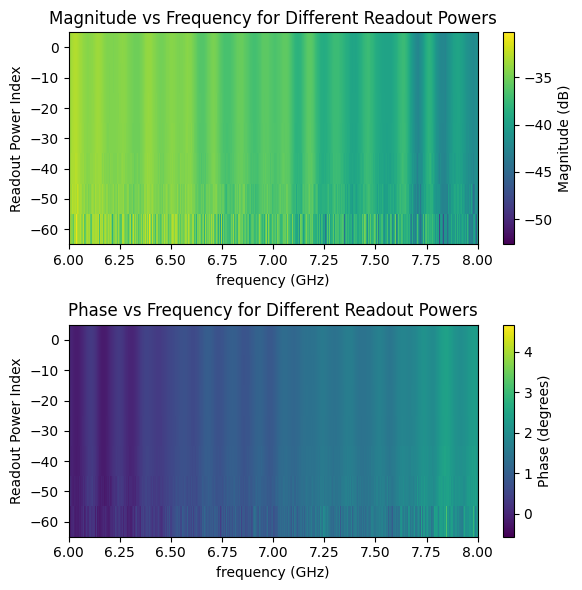

In [91]:
plt.figure(figsize=(6, 6))
plt.subplot(2, 1, 1)
plt.pcolormesh(freq_pow_sweep[0,:], RFpowers, mag_pow_sweep, shading='auto')
plt.colorbar(label='Magnitude (dB)')
plt.ylabel('Readout Power Index')
plt.title('Magnitude vs Frequency for Different Readout Powers')
plt.xlabel('frequency (GHz)')

plt.subplot(2, 1, 2)
plt.pcolormesh(freq_pow_sweep[0,:], RFpowers, phase_pow_sweep, shading='auto')
plt.colorbar(label='Phase (degrees)')
plt.ylabel('Readout Power Index')
plt.title('Phase vs Frequency for Different Readout Powers')
plt.xlabel('frequency (GHz)')
plt.tight_layout()

Text(0.5, 0, 'Frequency (GHz)')

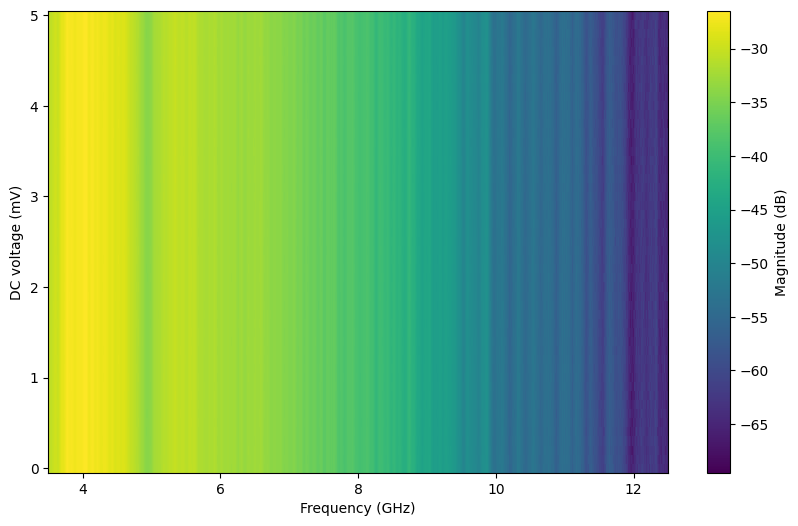

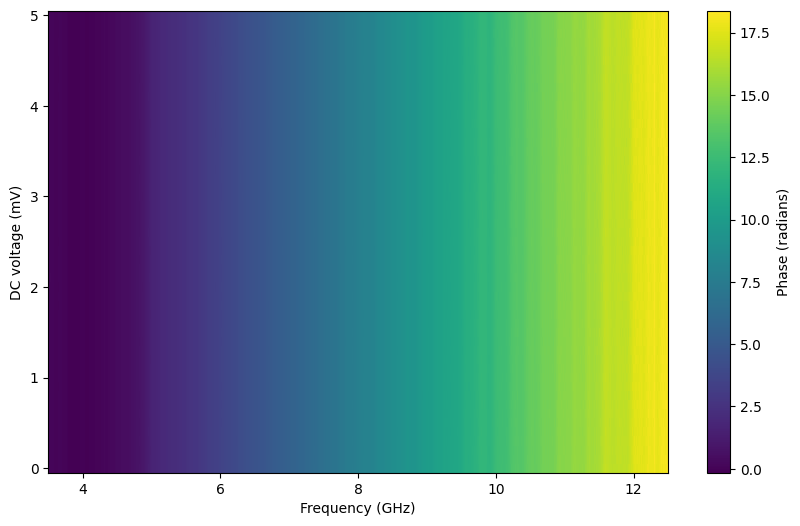

In [93]:
# load data from the pickle file
# freq_array, mag_array, phase_array = pickle.load(open('C:/_Data/SMPD/2026_04_30_JPA/JPA_dc_sweep.pkl', 'rb'))
num_dc_powers = len(freq_array)

# compute the slope of the phase response at 200 mV and from 5 to 7 GHz, then subtract it from the phase response at all DC powers
# dc_power_200mV_idx = np.argmin(abs(dc_powers-200))
# freq_zone = (freq_array[dc_power_200mV_idx,:]>5)&(freq_array[dc_power_200mV_idx,:]<7)
# phase_fit = np.polyfit(freq_array[dc_power_200mV_idx,:][freq_zone], phase_array[dc_power_200mV_idx,:][freq_zone], 1)
# phase_array = phase_array - np.polyval(phase_fit, freq_array)

# make a heatmap of the magnitude response as a function of frequency and DC power
plt.figure(figsize=(10,6)) 
plt.pcolormesh(freq_array[0,:], dc_powers, mag_array[:,:], shading='auto')
plt.colorbar(label='Magnitude (dB)')
plt.ylabel('DC voltage (mV)')
plt.xlabel('Frequency (GHz)')

plt.figure(figsize=(10,6)) 
plt.pcolormesh(freq_array[0,:], dc_powers, phase_array[:,:], shading='auto')
plt.colorbar(label='Phase (radians)')
plt.ylabel('DC voltage (mV)')
plt.xlabel('Frequency (GHz)')    

# plt.figure()
# freq_zone = (freq_array[0,:]>7.1)&(freq_array[0,:]<10.8)
# plt.plot(freq_array[0,:][freq_zone], phase_array[0,:][freq_zone])

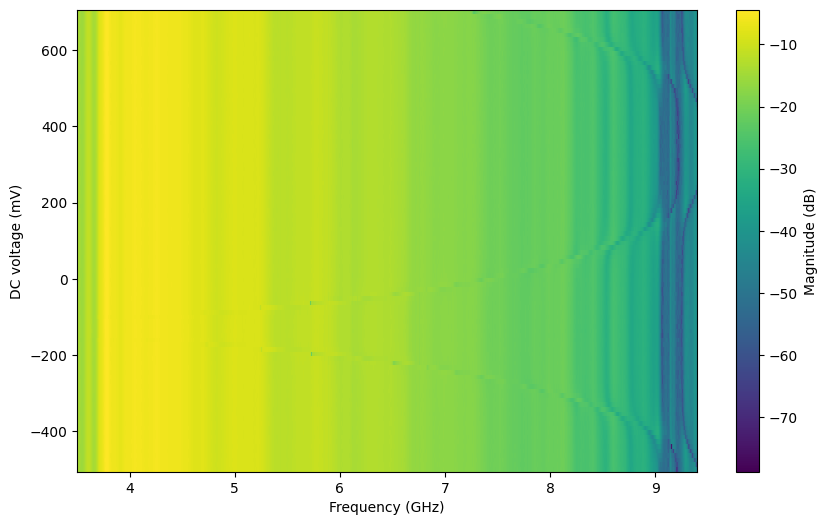

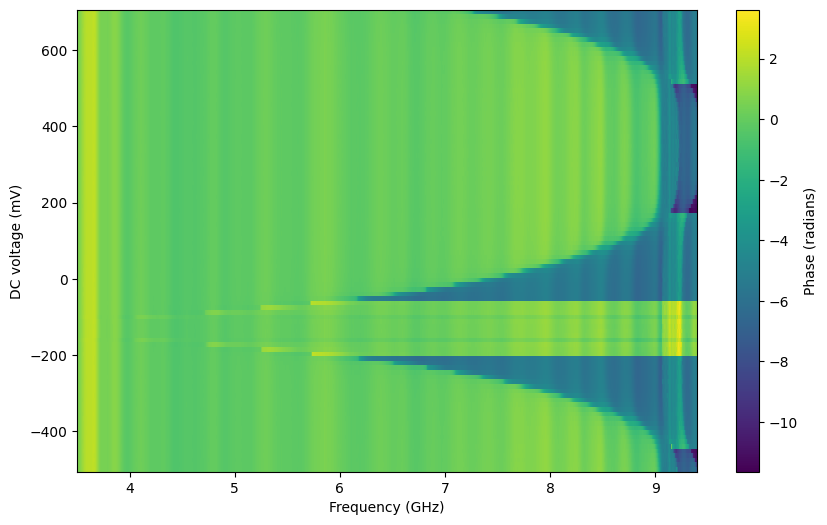

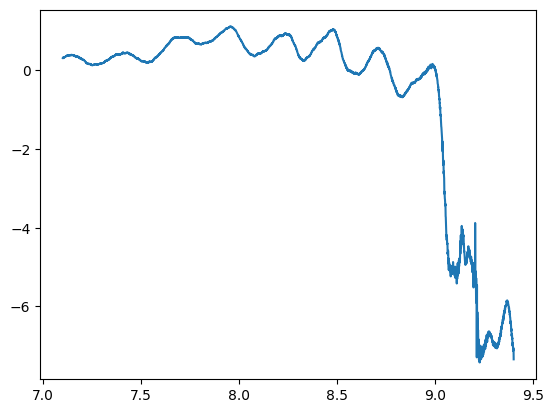

In [ ]:
# load data from the pickle file
freq_array, mag_array, phase_array = pickle.load(open('C:/_Data/SMPD/2026_04_30_JPA/JPA_dc_sweep.pkl', 'rb'))
num_dc_powers = len(freq_array)

# compute the slope of the phase response at 200 mV and from 5 to 7 GHz, then subtract it from the phase response at all DC powers
dc_power_200mV_idx = np.argmin(abs(np.linspace(-500,700,num_dc_powers)-200))
freq_zone = (freq_array[dc_power_200mV_idx,:]>5)&(freq_array[dc_power_200mV_idx,:]<7)
phase_fit = np.polyfit(freq_array[dc_power_200mV_idx,:][freq_zone], phase_array[dc_power_200mV_idx,:][freq_zone], 1)
phase_array = phase_array - np.polyval(phase_fit, freq_array)

# make a heatmap of the magnitude response as a function of frequency and DC power
plt.figure(figsize=(10,6)) 
plt.pcolormesh(freq_array[0,:], np.linspace(-500,700,num_dc_powers), mag_array[:,:], shading='auto')
plt.colorbar(label='Magnitude (dB)')
plt.ylabel('DC voltage (mV)')
plt.xlabel('Frequency (GHz)')

plt.figure(figsize=(10,6)) 
plt.pcolormesh(freq_array[0,:], np.linspace(-500,700,num_dc_powers), phase_array[:,:], shading='auto')
plt.colorbar(label='Phase (radians)')
plt.ylabel('DC voltage (mV)')
plt.xlabel('Frequency (GHz)')    

plt.figure()
freq_zone = (freq_array[0,:]>7.1)&(freq_array[0,:]<10.8)
plt.plot(freq_array[0,:][freq_zone], phase_array[0,:][freq_zone])

Voltages near 20 mV:
11.53846153846154
15.384615384615387
19.230769230769226
23.07692307692308
26.92307692307692


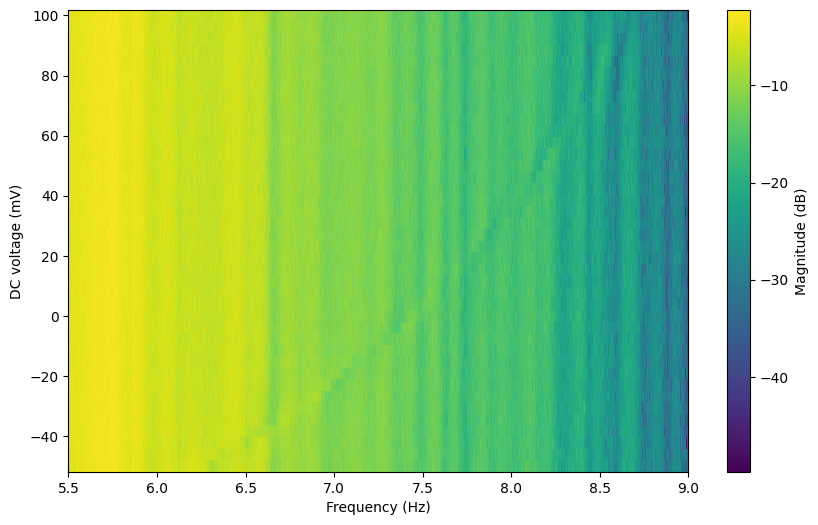

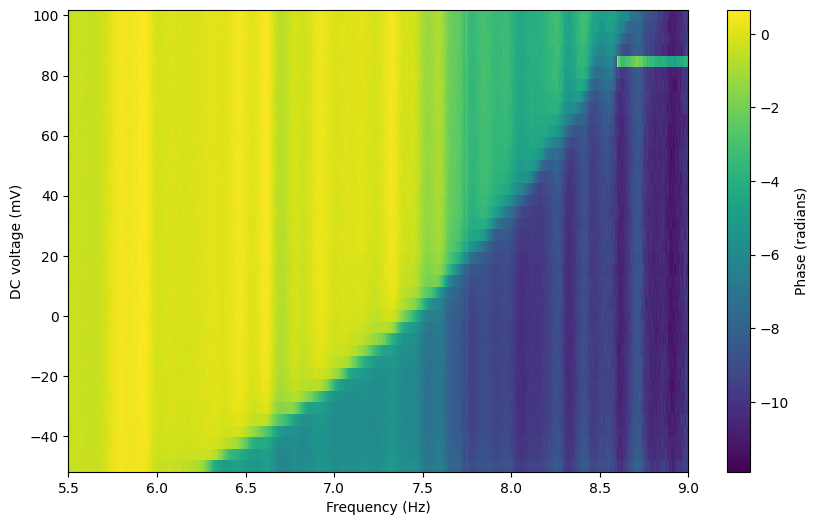

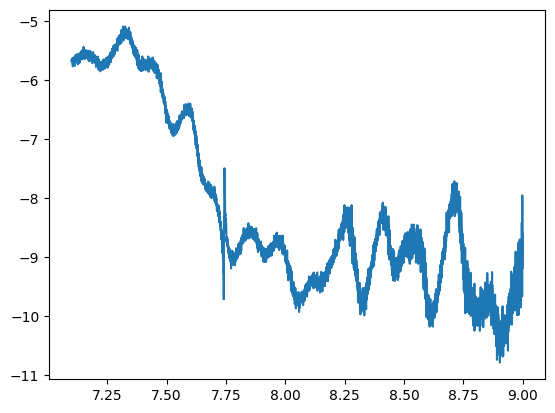

In [63]:
# load data from the pickle file
freq_array, mag_array, phase_array, dc_powers = pickle.load(open('C:/_Data/SMPD/2026_04_30_JPA/JPA_dc_sweep_across_waste.pkl', 'rb'))

# compute the slope of the phase response at 100 mV and from 5.5 to 7.5 GHz, then subtract it from the phase response at all DC powers
dc_power_100mV_idx = np.argmin(abs(dc_powers-100))
freq_zone = (freq_array[dc_power_100mV_idx,:]>5.5)&(freq_array[dc_power_100mV_idx,:]<7.5)
phase_fit = np.polyfit(freq_array[dc_power_100mV_idx,:][freq_zone], phase_array[dc_power_100mV_idx,:][freq_zone], 1)
phase_array = phase_array - np.polyval(phase_fit, freq_array)

# make a heatmap of the magnitude response as a function of frequency and DC power
plt.figure(figsize=(10,6)) 
plt.pcolormesh(freq_array[0,:], dc_powers, mag_array[:,:], shading='auto')
plt.colorbar(label='Magnitude (dB)')
plt.ylabel('DC voltage (mV)')
plt.xlabel('Frequency (Hz)')

plt.figure(figsize=(10,6)) 
plt.pcolormesh(freq_array[0,:], dc_powers, phase_array[:,:], shading='auto')
plt.colorbar(label='Phase (radians)')
plt.ylabel('DC voltage (mV)')
plt.xlabel('Frequency (Hz)')    

plt.figure()
freq_zone = (freq_array[0,:]>7.1)&(freq_array[0,:]<10.8)
plt.plot(freq_array[0,:][freq_zone], phase_array[0,:][freq_zone])

# print out voltages near 20 mV
print('Voltages near 20 mV:')
for i, dc_power in enumerate(dc_powers):
    if abs(dc_power-20) < 10:
        print(dc_power)

The DC voltage at which the resonant frequency is 7.745727 GHz is approximately 18.07 mV.


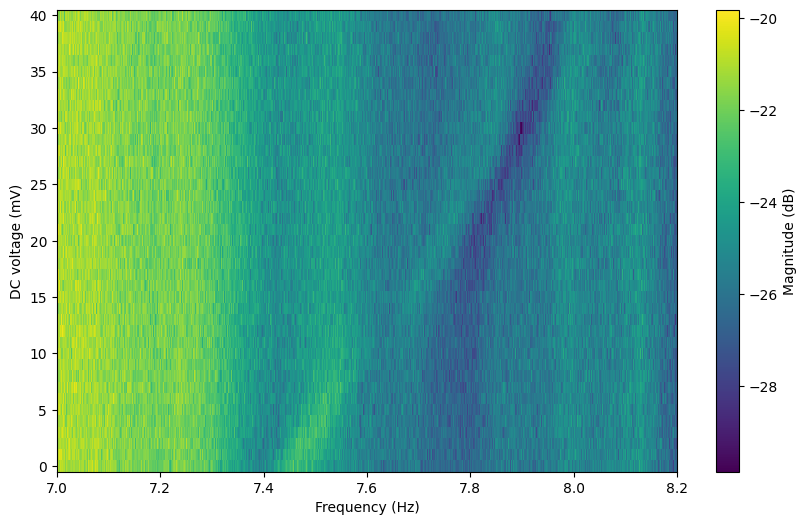

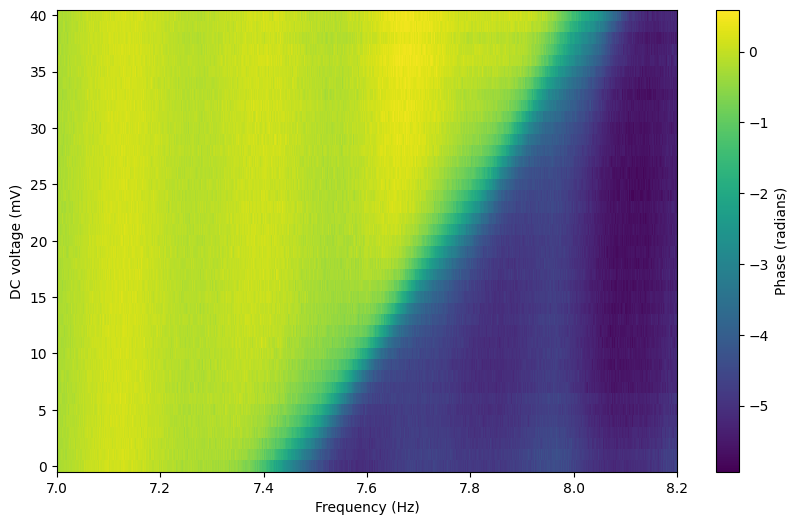

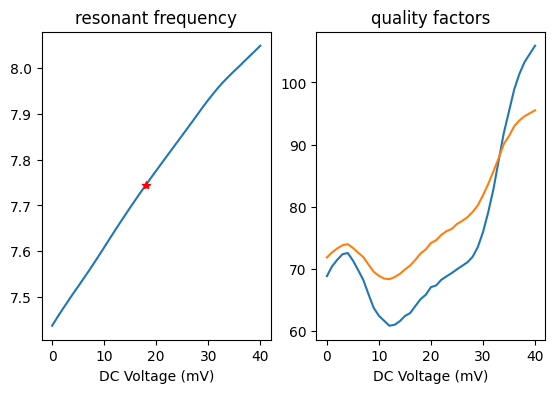

In [79]:
# load data from the pickle file
freq_array, mag_array, phase_array, dc_powers = pickle.load(open('C:/_Data/SMPD/2026_04_30_JPA/JPA_dc_sweep_zoom.pkl', 'rb'))

# compute the slope of the phase response at 40 mV and from 7.0 to 7.6 GHz, then subtract it from the phase response at all DC powers
dc_power_40mV_idx = np.argmin(abs(dc_powers-40))
freq_zone = (freq_array[dc_power_40mV_idx,:]>7.0)&(freq_array[dc_power_40mV_idx,:]<7.6)
phase_fit = np.polyfit(freq_array[dc_power_40mV_idx,:][freq_zone], phase_array[dc_power_40mV_idx,:][freq_zone], 1)
phase_array = phase_array - np.polyval(phase_fit, freq_array)

# make a heatmap of the magnitude response as a function of frequency and DC power
plt.figure(figsize=(10,6)) 
plt.pcolormesh(freq_array[0,:], dc_powers, mag_array[:,:], shading='auto')
plt.colorbar(label='Magnitude (dB)')
plt.ylabel('DC voltage (mV)')
plt.xlabel('Frequency (Hz)')

plt.figure(figsize=(10,6)) 
plt.pcolormesh(freq_array[0,:], dc_powers, phase_array[:,:], shading='auto')
plt.colorbar(label='Phase (radians)')
plt.ylabel('DC voltage (mV)')
plt.xlabel('Frequency (Hz)')    

# at each voltage, convert the phase response to S21 by taking 10^(mag/20)*exp(1j*phase), then fit the data using fitres.fine_fit()
num_dc_powers = len(dc_powers)
frs = np.zeros(num_dc_powers)
Qrs = np.zeros(num_dc_powers)
Qcs = np.zeros(num_dc_powers)
for i in range(len(dc_powers)):
    S21 = 10**(mag_array[i,:]/20) * np.exp(1j*phase_array[i,:])
    

    # compute the derivative of the phase averaged over 200 points, then find the index of the maximum derivative, which is a good initial guess for the resonant frequency
    phase_derivative = np.gradient(phase_array[i,:])
    phase_derivative_avg = np.convolve(phase_derivative, np.ones(200)/200, mode='same')
    max_idx = np.argmax(phase_derivative_avg)

    params = fitres.finefit(freq_array[i,:], S21, [freq_array[i,:][max_idx]])
    frs[i] = params[0]; Qrs[i] = params[1]; Qcs[i] = params[6]*2

    # if fr is more than 0.05 GHz away from the last fr, plot the data and the fit to check if the fit is good
    if i > 0 and abs(frs[i] - frs[i-1]) > 0.05 and not np.isnan(frs[i]) and not np.isnan(frs[i-1]):
        plt.figure(figsize=(10,6))
        plt.plot(S21.real, S21.imag,ls='',marker='.')
        plt.plot(S21.real[max_idx], S21.imag[max_idx], 'ro', label='Initial Guess')

        S21_fit = fitres.resfunc3(freq_array[i,:], *params[:6])
        plt.plot(S21_fit.real, S21_fit.imag)
        plt.xlabel('Frequency (GHz)')
        plt.ylabel('Magnitude (dB)')
        plt.title(f'Fit at DC voltage {dc_powers[i]} mV')
        plt.axis('equal')
        plt.legend()
        plt.grid(True)
        plt.show()

fig,ax = plt.subplots(figsize=(6.5,4),nrows=1,ncols=2)
titles = ['resonant frequency', 'quality factors'] 
ax[0].plot(dc_powers, frs, label='Resonant Frequency (GHz)')
ax[1].plot(dc_powers, Qrs, label='Total Quality Factor')
ax[1].plot(dc_powers, Qcs, label='Coupling Quality Factor')
for i in range(2):
    ax[i].set_xlabel('DC Voltage (mV)')
    # ax[i].set_ylabel('Frequency (GHz) or Quality Factor')
    ax[i].set_title(titles[i])

# interpolate fr vs dc voltage to find the voltage at which fr is at the frequency target
frequency_target = waste_resonance - 7.74 + waste_resonance
from scipy.interpolate import interp1d
fr_interp = interp1d(dc_powers, frs, kind='cubic')
dc_voltage_frequency_target = interp1d(frs, dc_powers, kind='cubic')(frequency_target)
print(f'The DC voltage at which the resonant frequency is {frequency_target:.6f} GHz is approximately {dc_voltage_frequency_target:.2f} mV.')

# put a star at the point where fr is equal to waste_resonance on the plot of fr vs dc voltage
ax[0].plot(dc_voltage_frequency_target, frequency_target, 'r*', label=f'fr = {frequency_target:.6f} GHz')


BFG_C10.pkl
BFG_C11.pkl
BFG_C5.pkl
BFG_C8.pkl


(3.0, 5.0)

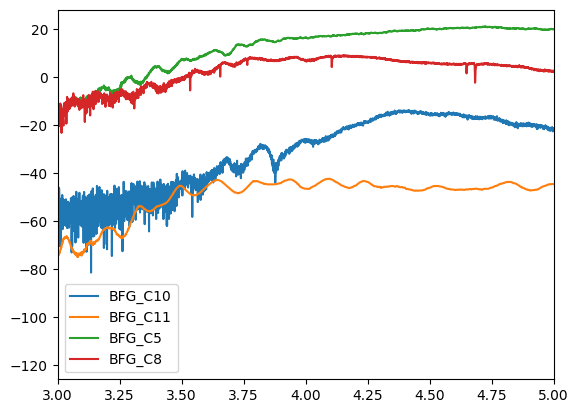

In [20]:
#plot the data in the C:\_Data\SMPD\2026_03_14 folder, only those starting with BFG
data_dir = 'C:/_Data/SMPD/2026_03_14'
for file in os.listdir(data_dir):
    # skip C6 file
    if file.endswith('.pkl') and file.startswith('BFG') and not 'C6' in file:
        print(file)
        freq_all, mag_all, phase_all = pickle.load(open(os.path.join(data_dir, file), 'rb'))
        plt.plot(freq_all, mag_all,label=file.split('/')[-1].split('.')[0])
plt.legend()
plt.xlim(3,5)